In [1]:
import numpy as np
import os
import pickle
import torch
import matplotlib.pyplot as plt
import math
import matplotlib.collections as mcoll
from scipy.interpolate import interp1d
import matplotlib.cm as cm

In [2]:
path_to_run = "/vision/asomaya1/active-rir/runs"
context_obs_file_name = "context_visualization.pkl"
#change this to desired model
run = "US_C_all_subg_queries"
context_obs_path = os.path.join(path_to_run, run, "tb", context_obs_file_name)

In [3]:
with open(context_obs_path, 'rb') as file:
    loaded_list = pickle.load(file)

In [4]:
loaded_list, query_poses, pred_rirs = loaded_list
pred_rirs = pred_rirs.cpu().squeeze()

In [5]:
def plot_log_spectrograms_grid(tensor):
    """
    Plots a grid of log spectrograms for the first channel of each spectrogram in the tensor.

    Args:
    tensor (np.array): A 4D numpy array of shape (60, 256, 259, 2) representing 60 2-channel spectrograms.
    """
    # Create a 20x3 subplot grid
    fig, axes = plt.subplots(5, 3, figsize=(10, 30))

    # Iterate through the tensor and plot each spectrogram's first channel
    images = []
    for i in range(5):
        for j in range(3):
            index = i * 3 + j
            if index < tensor.shape[0]:
                pred_spect_mag = torch.exp(tensor[index, :, :, 0])\
                                            - 1e-8
                log_spectrogram = pred_spect_mag
                #log_spectrogram = np.log1p(np.abs(tensor[index, :, :, 0]))
                im = axes[i, j].imshow(log_spectrogram, aspect='auto', origin='lower')
                axes[i, j].imshow(log_spectrogram, aspect='auto', origin='lower')
                axes[i, j].set_title(f'Spectrogram {index+1}')
                axes[i, j].axis('off')
                images.append(im)
            else:
                axes[i, j].axis('off')  # Turn off axes for grids with no data

    fig.colorbar(images[-1], ax=axes.ravel().tolist(), orientation='horizontal', pad=0.02)
    plt.tight_layout()
    return fig

In [6]:
# Function to plot RGB, Depth, and both channels of Spectrogram
def plot_rgb_depth_spect(rgb, depth, spect):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3))  # Adjusted for 5 subplots

    # Normalize RGB image to [0, 1]
    normalized_rgb = rgb / 255.0

    # RGB image
    axes[0].imshow(normalized_rgb)
    axes[0].set_title('RGB')
    axes[0].axis('off')

    # Depth image
    depth_image = depth.numpy()
    axes[1].imshow(depth_image, cmap='gray')
    axes[1].set_title('Depth')
    axes[1].axis('off')

    # Spectrogram Channel 1
    axes[2].imshow(spect[:, :, 0].T, aspect='auto')
    axes[2].set_title('Spectrogram Ch1')
    axes[2].axis('off')

    # Spectrogram Channel 2
    axes[3].imshow(spect[:, :, 1].T, aspect='auto')
    axes[3].set_title('Spectrogram Ch2')
    axes[3].axis('off')

    plt.tight_layout()
    return fig

In [7]:
# Function to plot poses with orientation
def plot_poses_with_orientation(poses, plot_line=True, pad=10):
    fig, ax = plt.subplots(figsize=(6, 6))
    arrow_length = 0.5  # Fixed arrow length

    # Extracting x and y coordinates
    x_coords = [-pose[3] for pose in poses]
    y_coords = [pose[2] for pose in poses]

    if plot_line:
        # Interpolating for smoothness
        num_points = 300  # Number of points for interpolation
        time = np.linspace(0, 1, len(poses))
        time_smooth = np.linspace(0, 1, num_points)
        f_interp_x = interp1d(time, x_coords, kind='cubic')
        f_interp_y = interp1d(time, y_coords, kind='cubic')

        x_smooth = f_interp_x(time_smooth)
        y_smooth = f_interp_y(time_smooth)


        # Create a color map for the line
        norm = plt.Normalize(0, 1)
        points = np.array([x_smooth, y_smooth]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
        lc.set_array(time_smooth)
        ax.add_collection(lc)

    # Get a colormap for the arrows and dots
    cmap = cm.get_cmap('Greys')

    # Iterate over poses with index
    for index, pose in enumerate(poses):
        x, y, _, _, theta = pose  # Assuming the pose format is [x, y, theta]
        y = -y

        # Calculate color based on index
        color = cmap(float(index)+1 / len(poses))

        # Plot pose location with varying color
        ax.plot(x, y, 'o')  # Pose location

        # Calculating arrow direction based on theta
        dx = arrow_length * math.cos(theta)
        dy = arrow_length * math.sin(theta)

        # Drawing arrow with fixed size and varying color
        ax.arrow(x, y, dx, dy, head_width=0.2, head_length=0.3, fc=color, ec=color)

    ax.set_title('Poses with Orientation')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.grid(True)
    # Adjust axis limits to make the plot square
    x_range = 10#max(x_coords) - min(x_coords) + pad
    y_range = 10#max(y_coords) - min(y_coords) + pad
    max_range = 25 #max(x_range, y_range) / 2

    mid_x = 0 #(max(x_coords) + min(x_coords)) / 2
    mid_y = 0 #(max(y_coords) + min(y_coords)) / 2

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)

    plt.tight_layout()
    return fig

/tmp/ipykernel_1060763/3895025047.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 6))
/tmp/ipykernel_1060763/3895025047.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Greys')


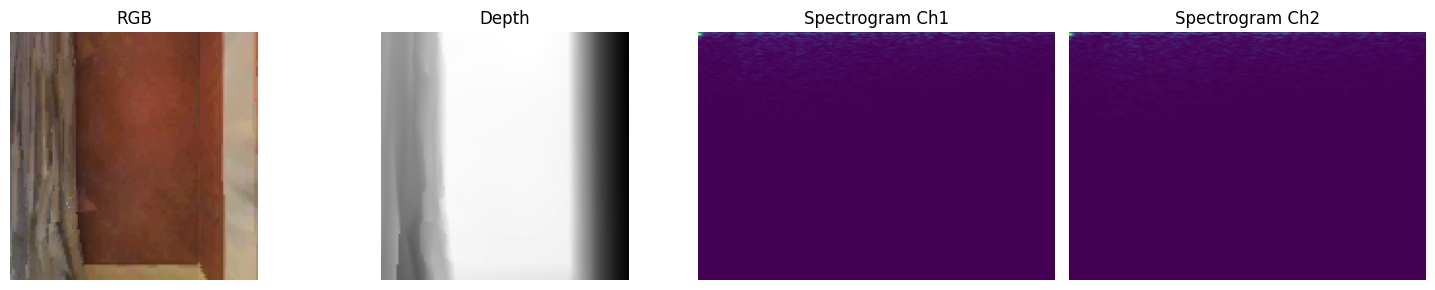

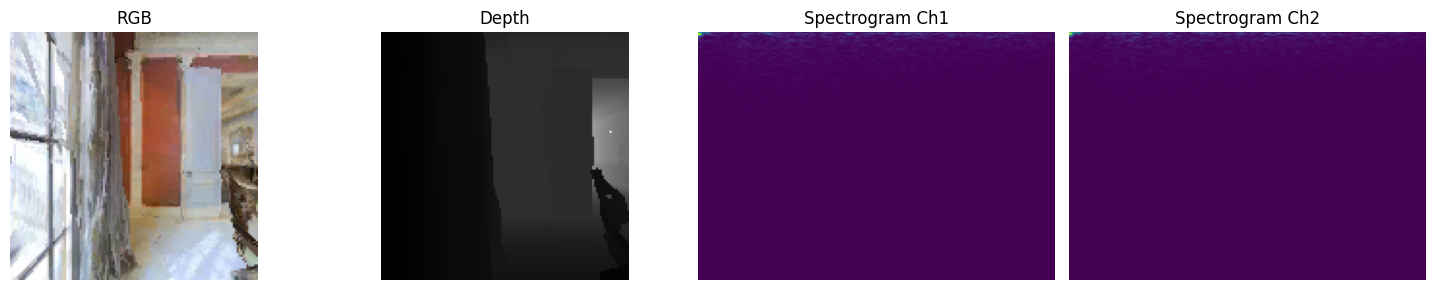

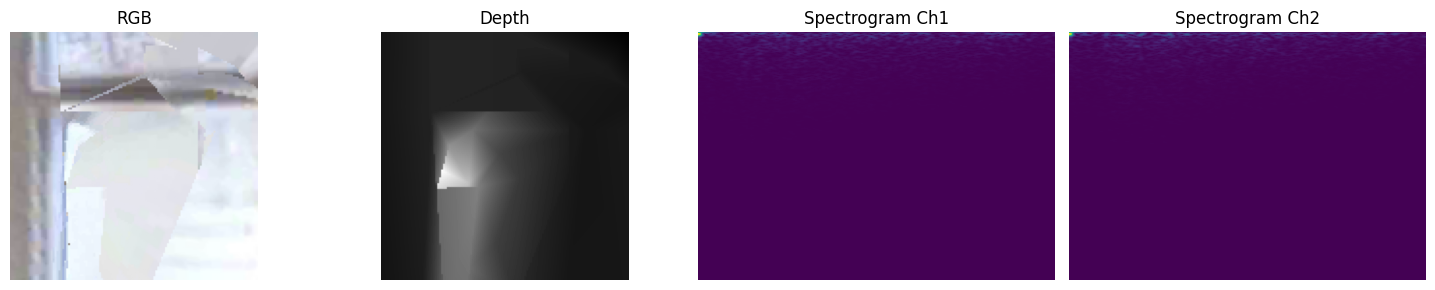

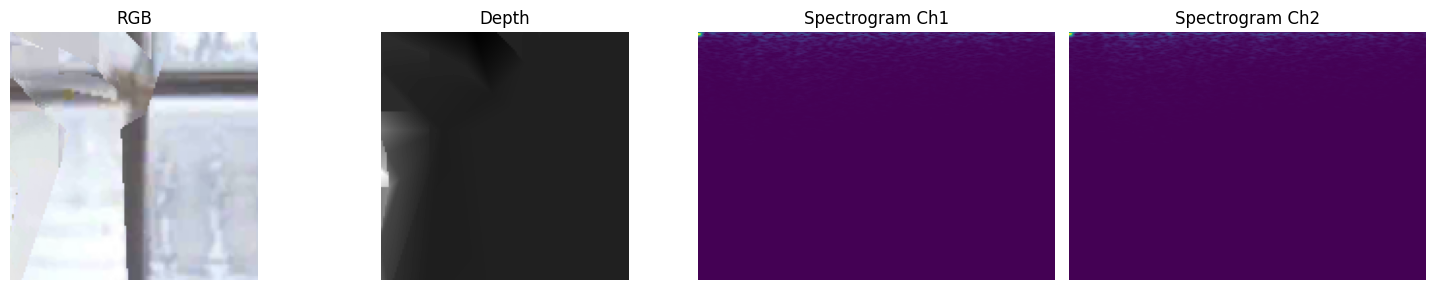

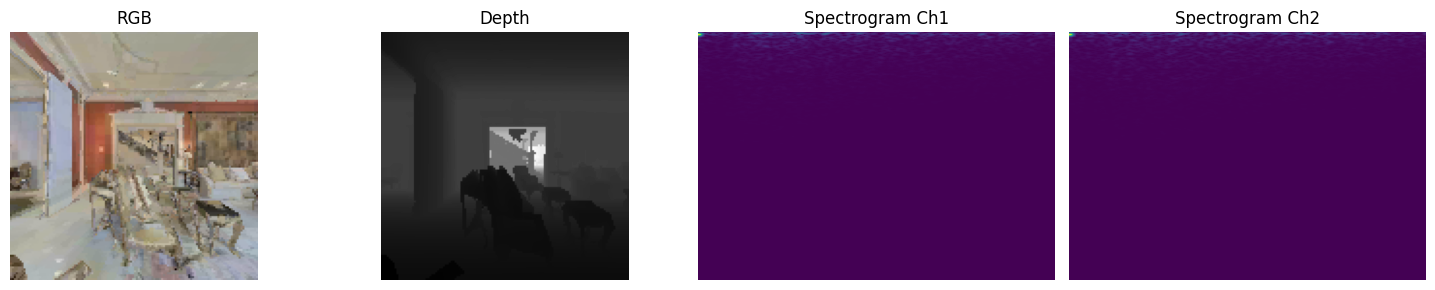

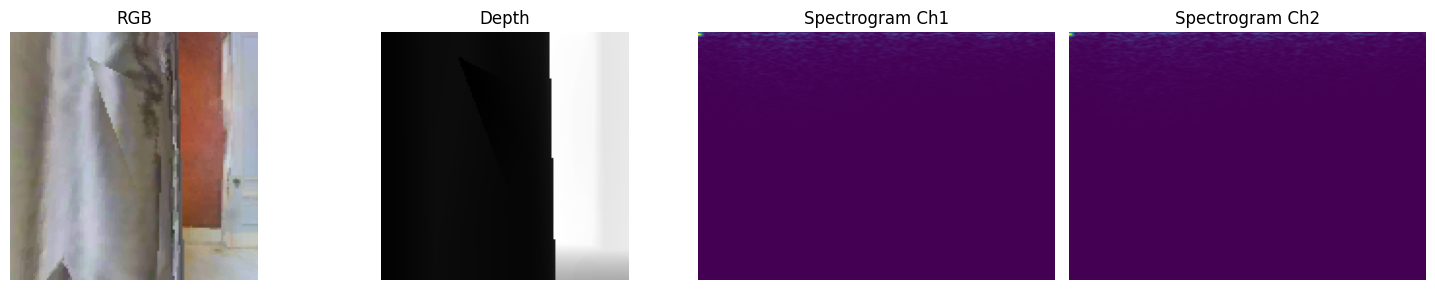

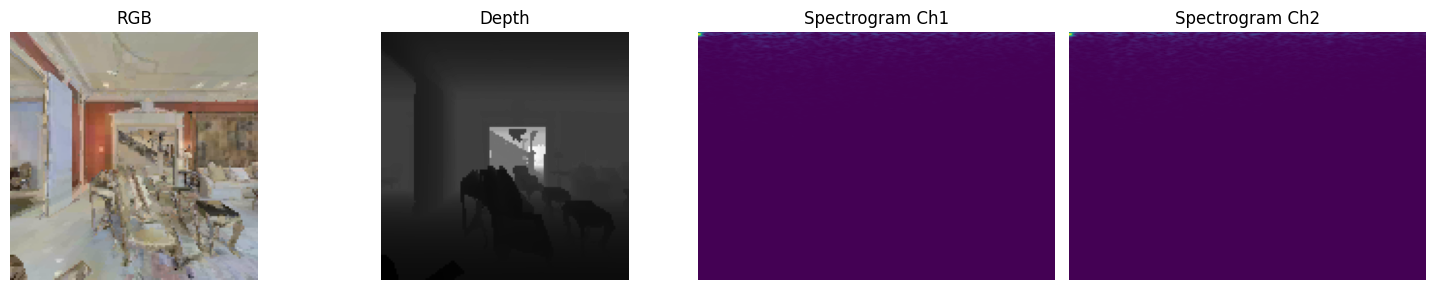

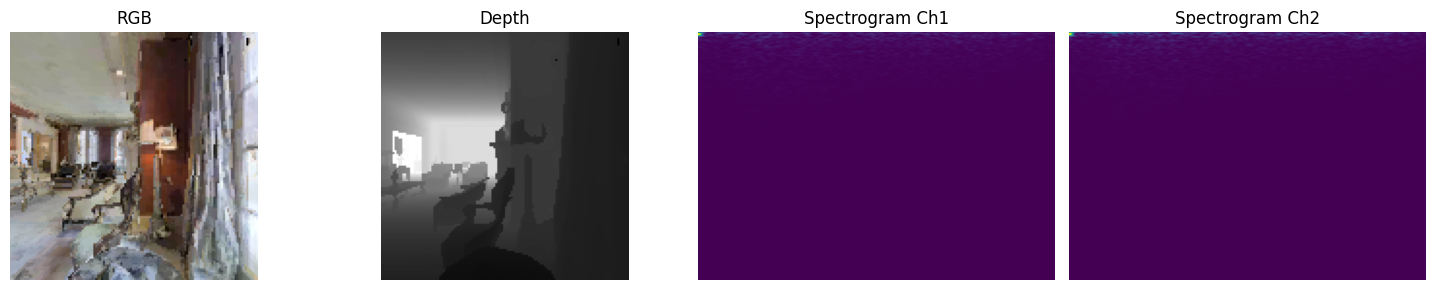

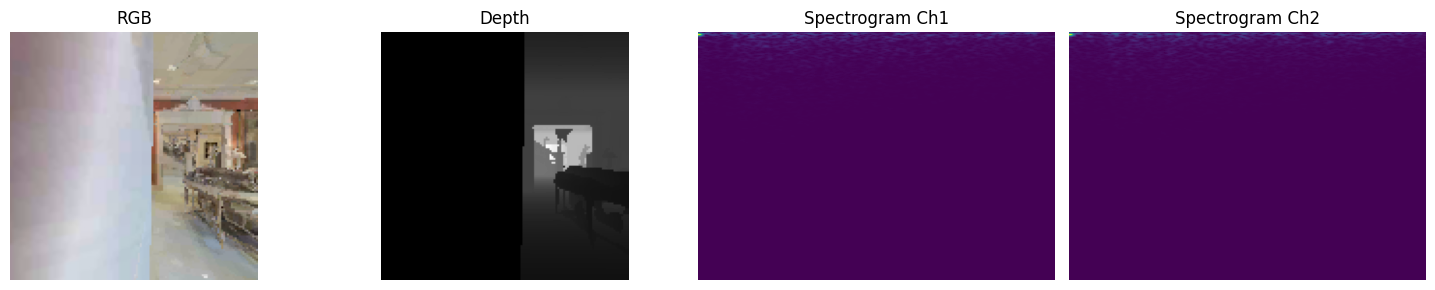

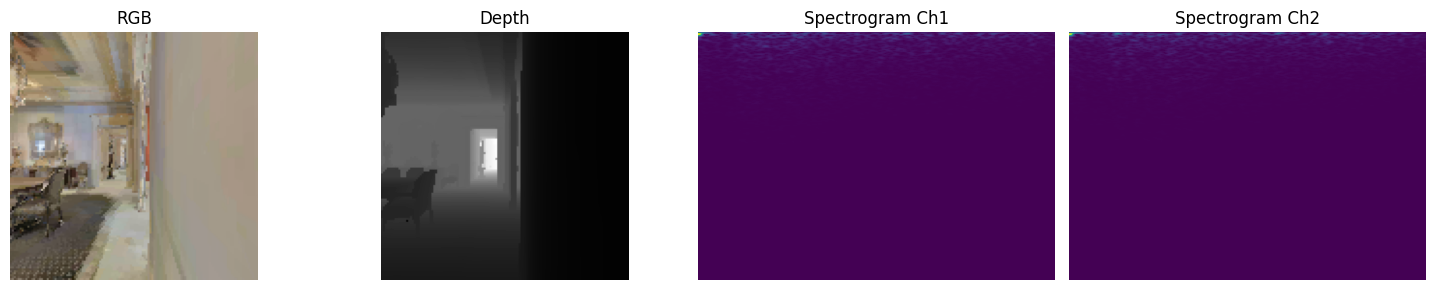

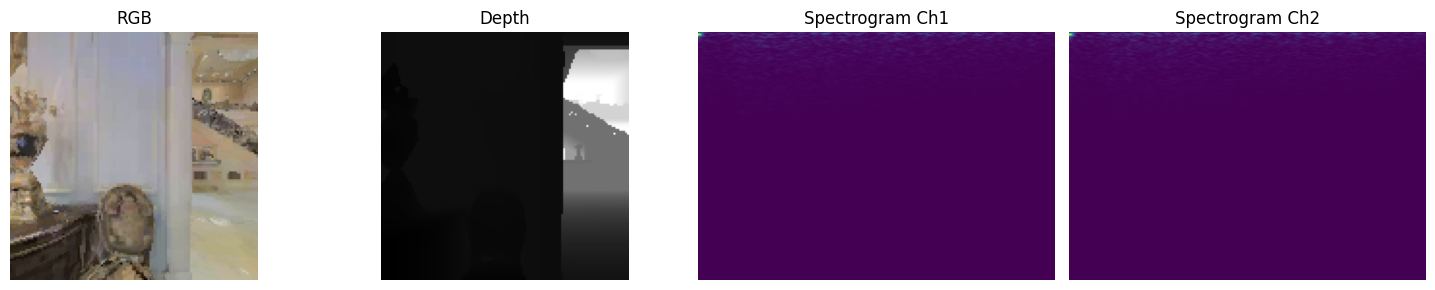

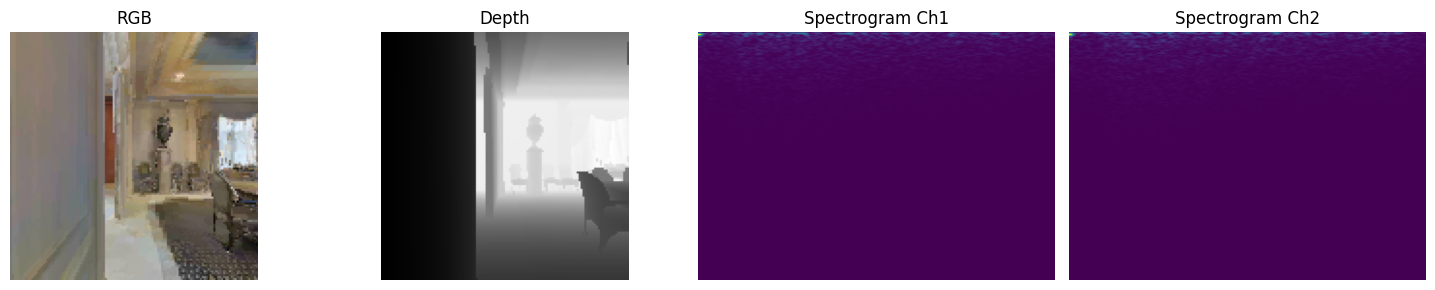

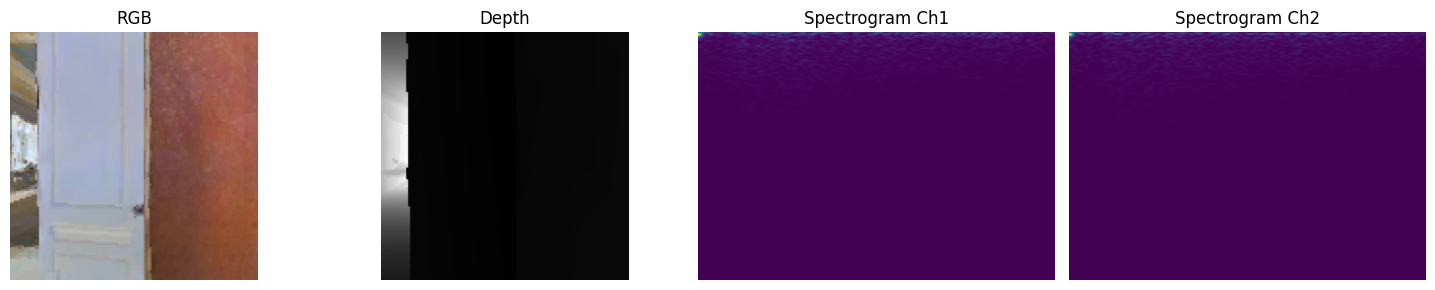

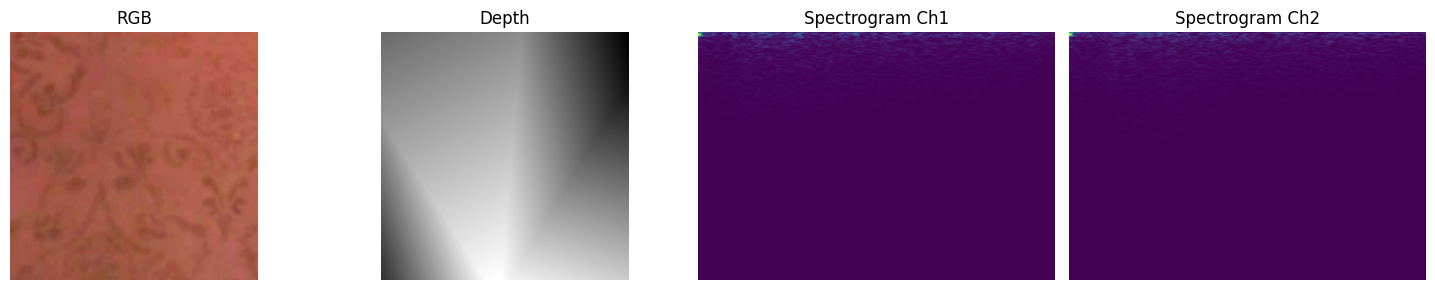

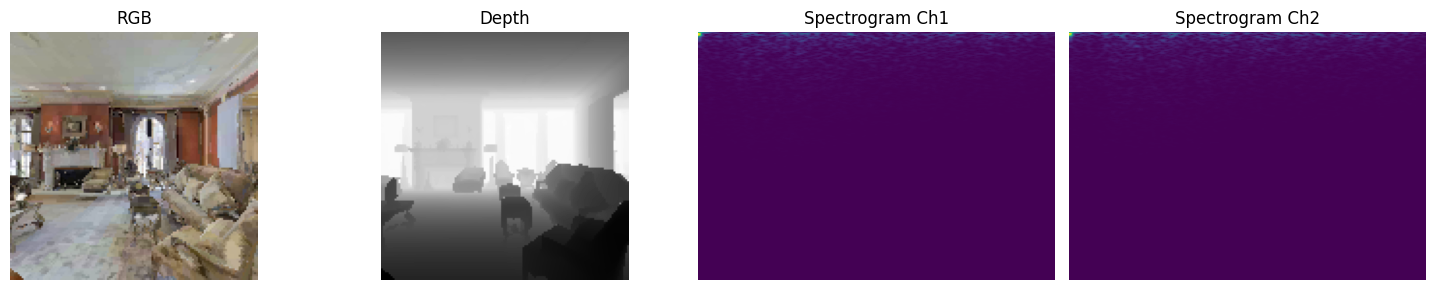

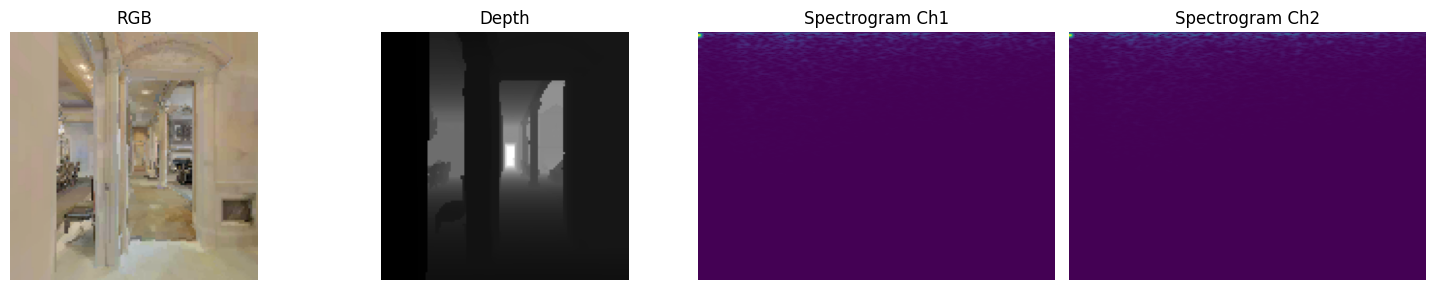

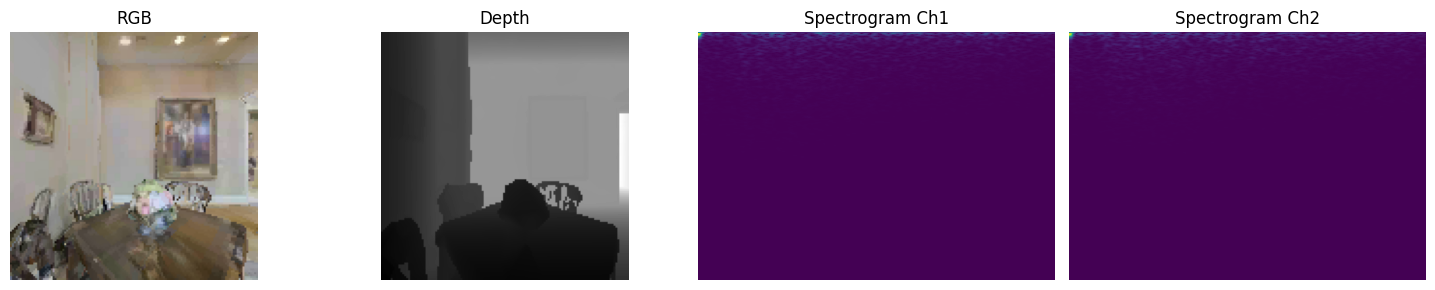

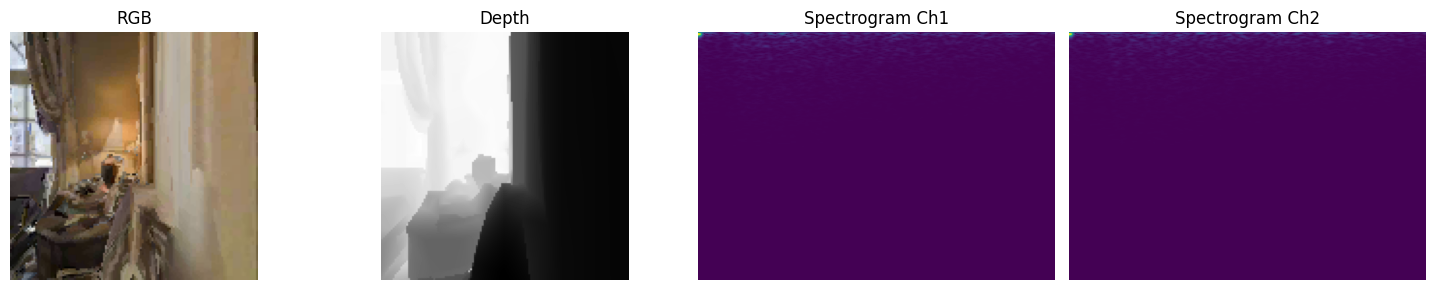

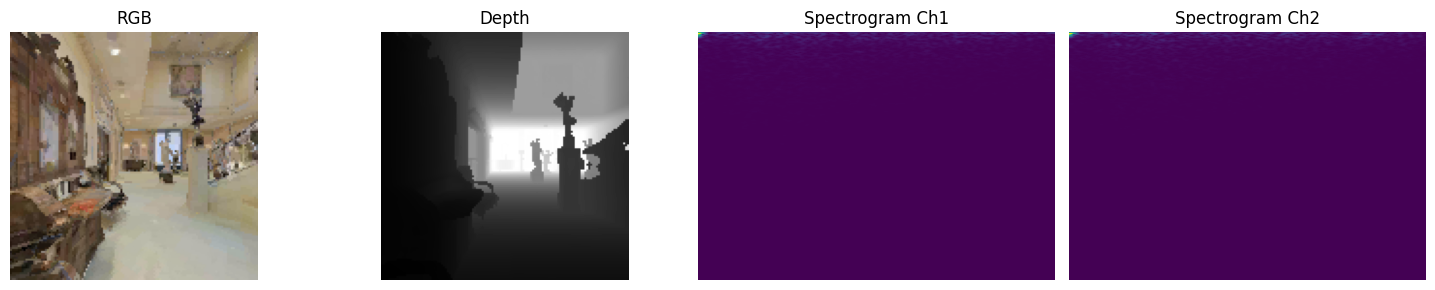

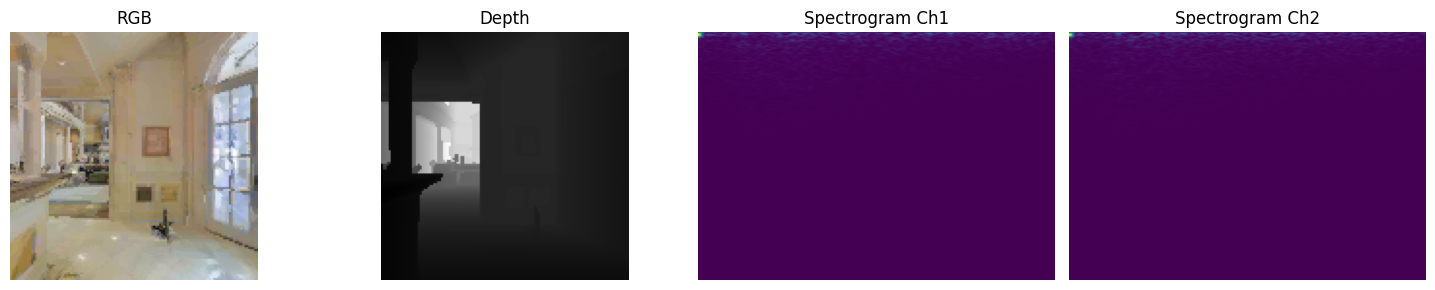

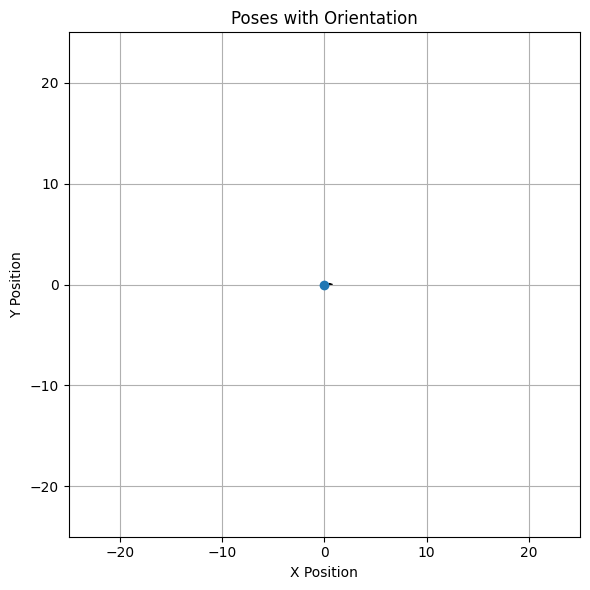

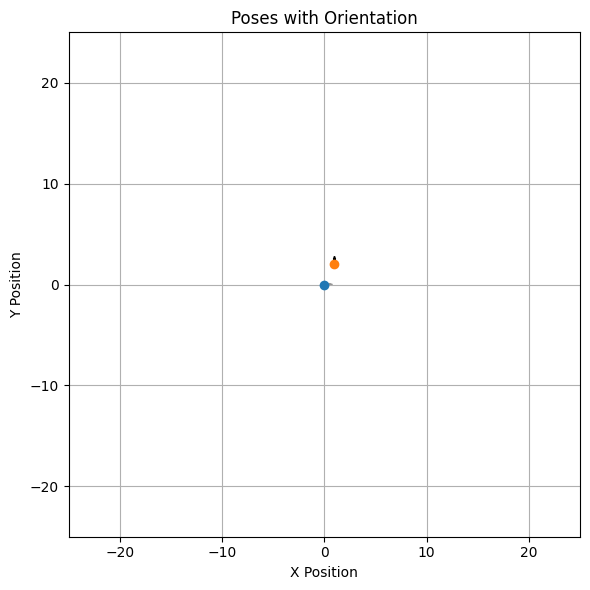

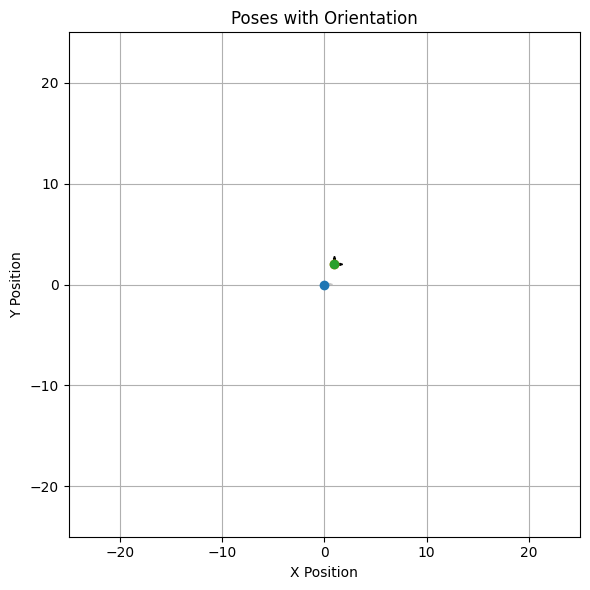

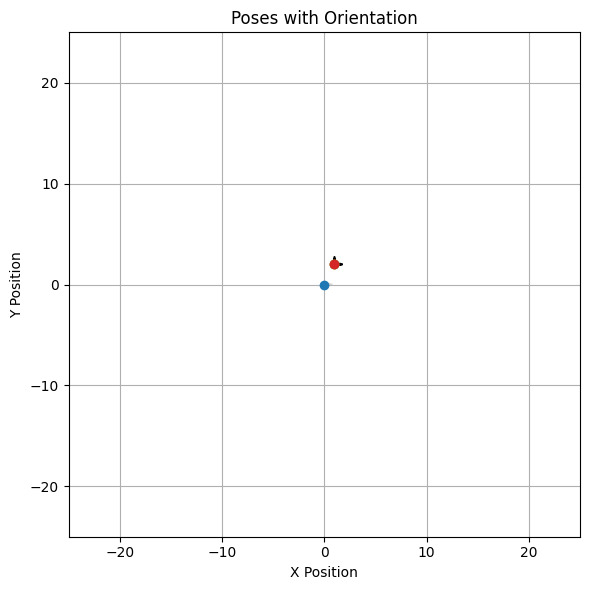

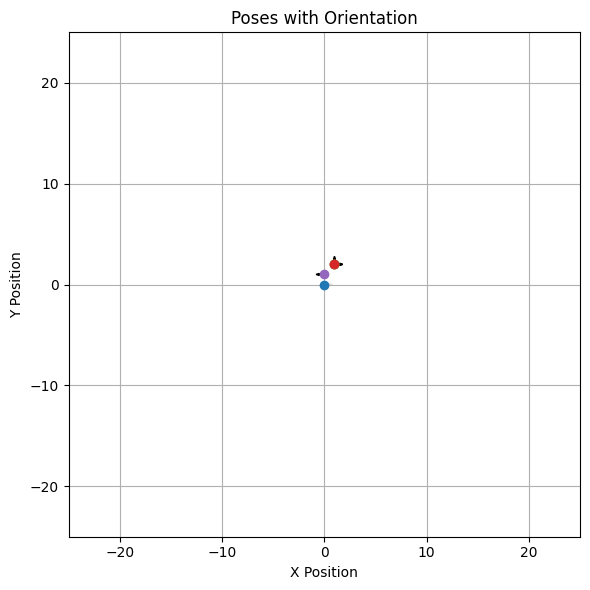

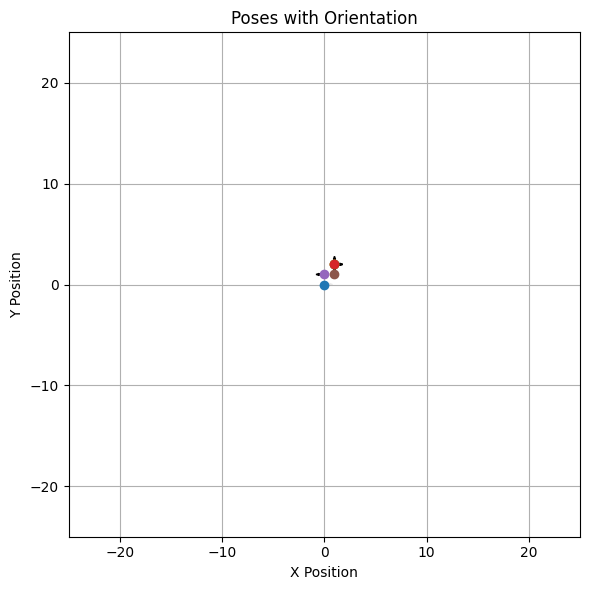

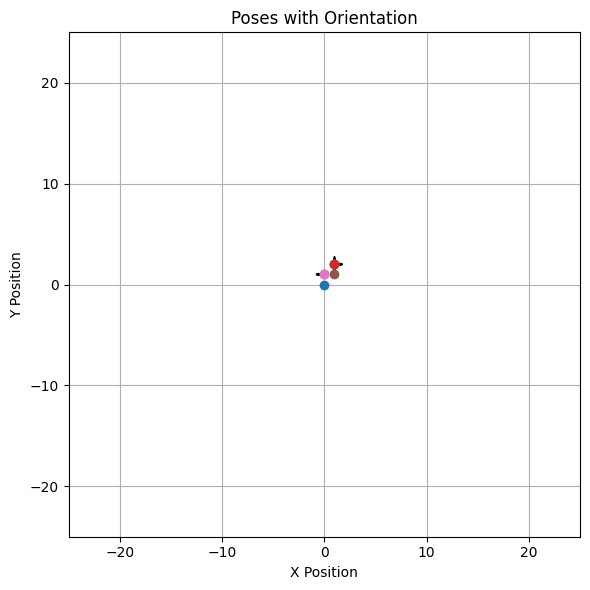

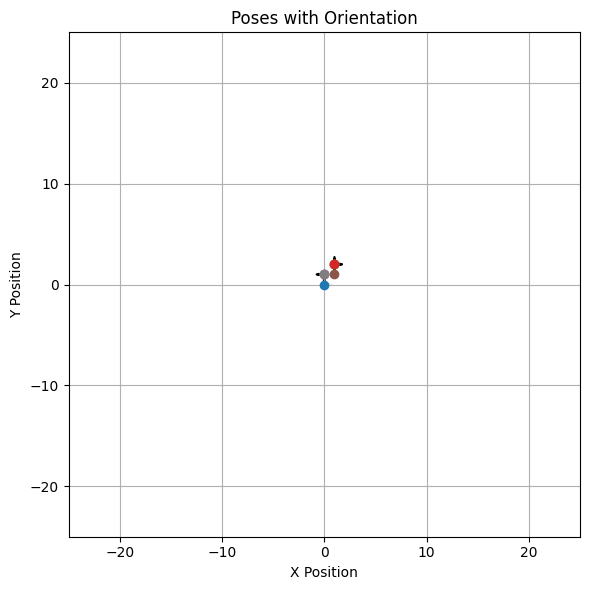

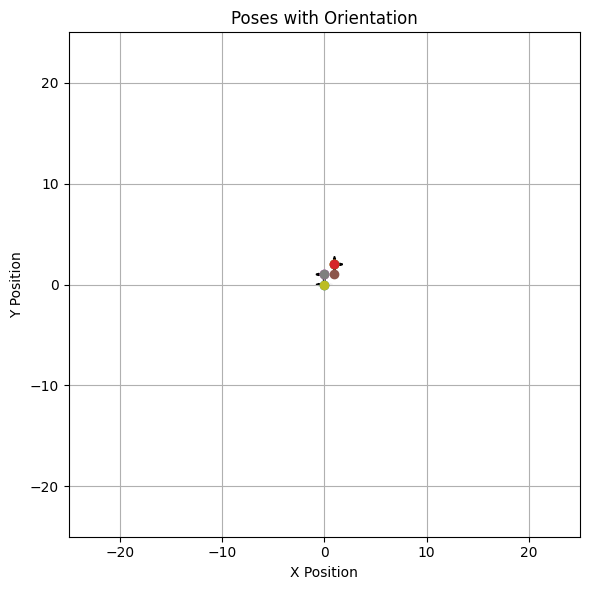

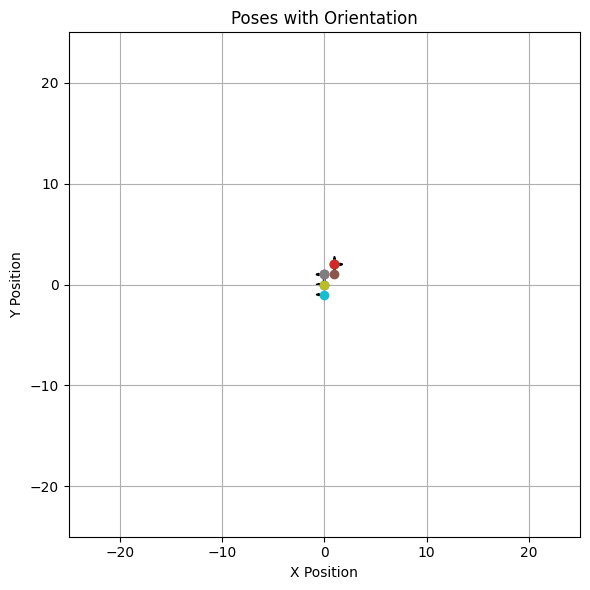

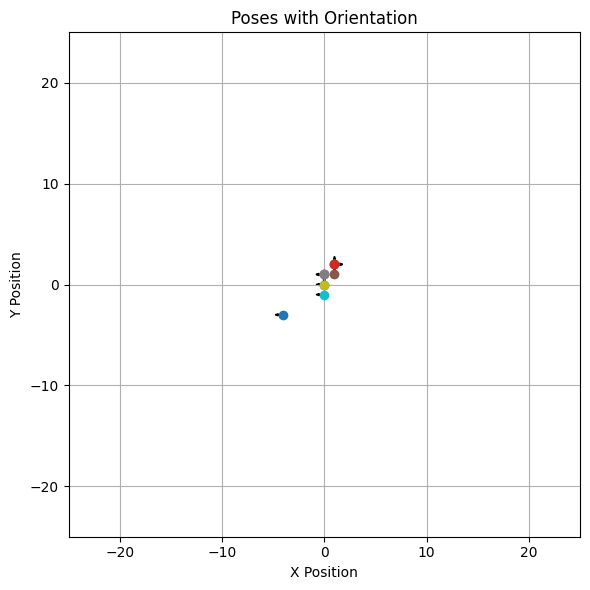

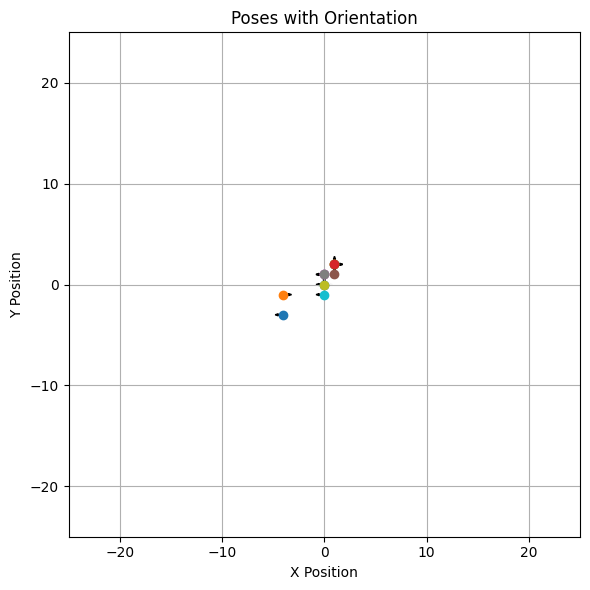

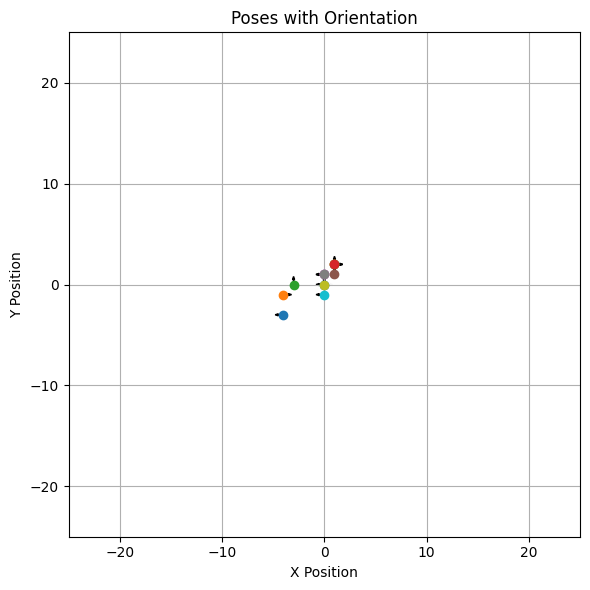

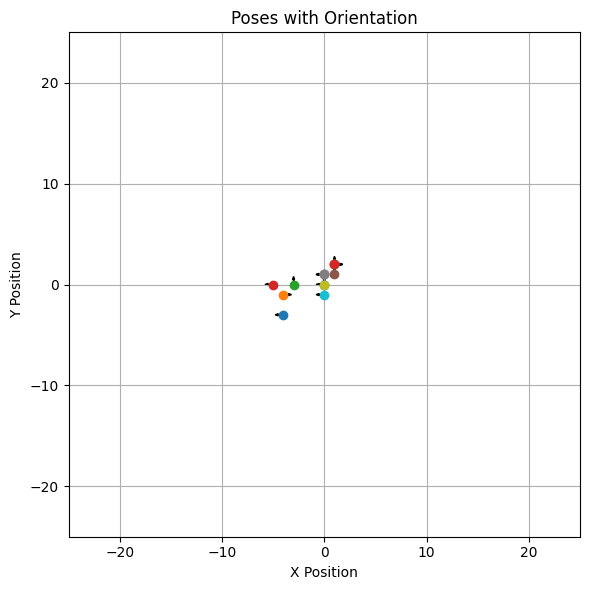

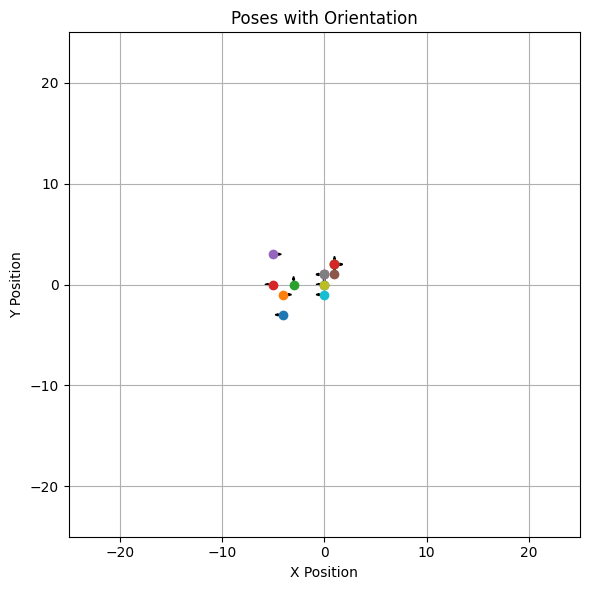

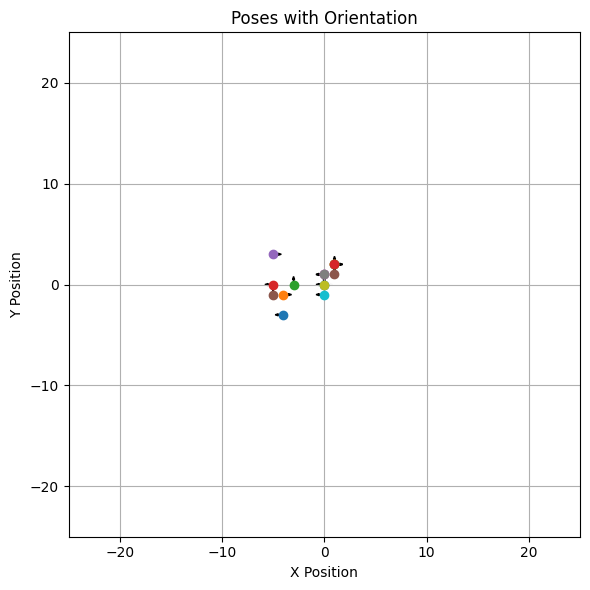

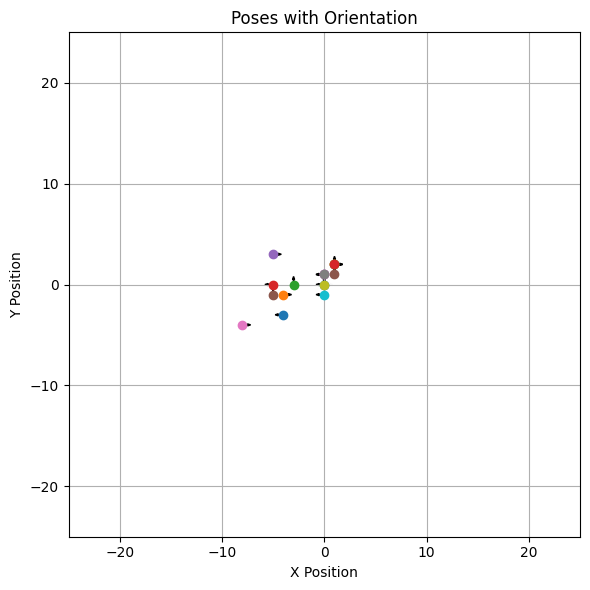

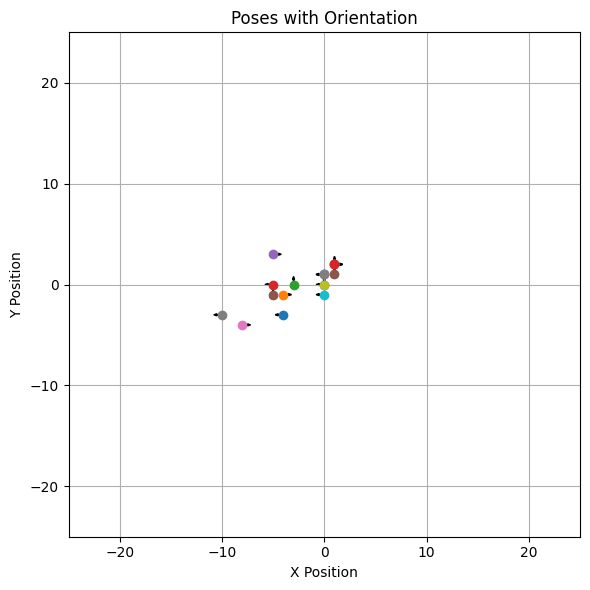

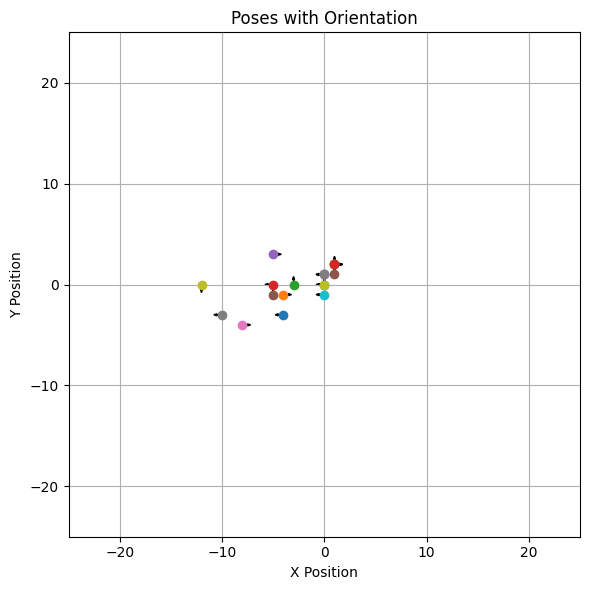

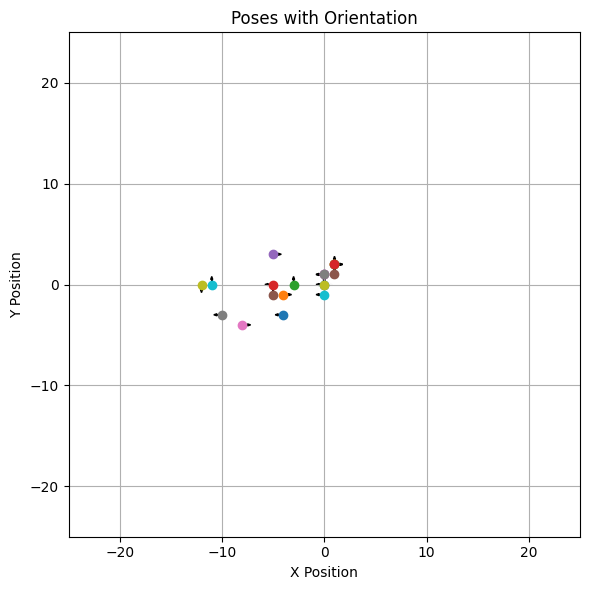

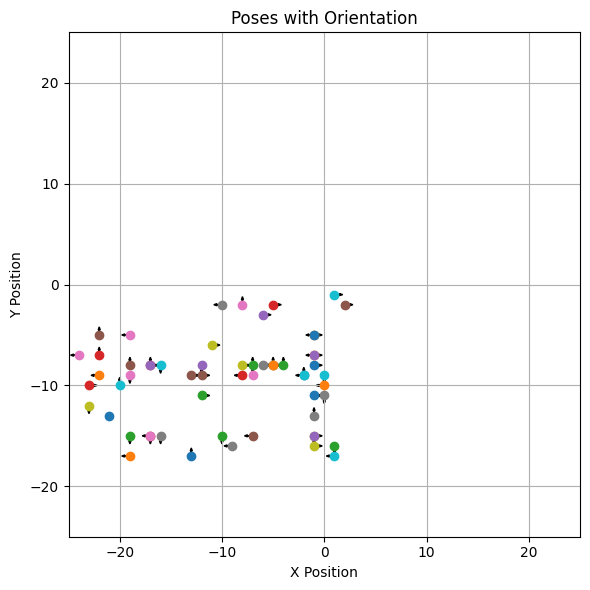

In [8]:
# Assuming mock_data is already created
# Visualize each item in the dataset
for item in loaded_list:
    plot_rgb_depth_spect(item['rgb'], item['depth'].squeeze(), item['bin_spect_mag'])

# Extracting and plotting pose data with orientation
pose_data = [item['pose'] for item in loaded_list]
for i in range(len(pose_data)):
    plot_poses_with_orientation(pose_data[:i+1], plot_line=False)

# Extracting and plotting pose data with orientation
plot_poses_with_orientation(np.array(query_poses), plot_line=False, pad=30)

# Show all plots
plt.show()

In [ ]:
import os
import random
import numpy as np
import librosa
from scipy.io import wavfile
import matplotlib.pyplot as plt

def load_wav_to_spectrogram(file_path):
    # Load the .wav file
    fs_imp, sig_imp = wavfile.read(file_path)

    if len(sig_imp) == 0:
            sig_imp = np.zeros((16000, 2)).astype("float32")
            fs_imp = 16000

    imp_full_length = np.zeros((16000, 2))

    if sig_imp.shape[0] > 128:
        imp_full_length[: min(sig_imp.shape[0], 16000) - 128] =\
            sig_imp[128: min(sig_imp.shape[0], 16000), :]    # remove the first 127 zero samples
    
    sig_imp = imp_full_length
    assert fs_imp == 16000
    sig_imp = sig_imp.T
    fft_windows_l_imp = librosa.stft(np.asfortranarray(sig_imp[0]),
                                        hop_length=62,
                                        n_fft=511,
                                        win_length=248 if (248 != 0) else None,)
    magnitude_l_imp, _ = librosa.magphase(fft_windows_l_imp)
    fft_windows_r_imp = librosa.stft(np.asfortranarray(sig_imp[1]),
                                        hop_length=62,
                                        n_fft=511,
                                        win_length=248 if (248 != 0) else None,)
    magnitude_r_imp, _ = librosa.magphase(fft_windows_r_imp)    
    magnitude_imp = np.stack([magnitude_l_imp, magnitude_r_imp], axis=-1)
    magnitude_imp = magnitude_imp.astype("float32")

    # Return the spectrogram
    return magnitude_imp

def display_spectrogram(spectrogram):
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Spectrogram Channel 1
    axes[0].imshow(spectrogram[:, :, 0].T, aspect='auto')
    axes[0].set_title('Spectrogram Ch1')
    axes[0].axis('off')

    # Spectrogram Channel 2
    axes[1].imshow(spectrogram[:, :, 1].T, aspect='auto')
    axes[1].set_title('Spectrogram Ch2')
    axes[1].axis('off')


# Directory containing the .wav files
directory = "/vision/asomaya1/active-rir/data/binaural_rirs/mp3d/Z6MFQCViBuw/0"

# Find all .wav files in the directory
wav_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.wav') and f.split("_")[-1].split(".")[0] == f.split("_")[0].split("/")[-1]]

# Randomly select 5 files
selected_files = random.sample(wav_files, 1)

# Process and display each file
for file in selected_files:
    spectrogram = load_wav_to_spectrogram(file)
    display_spectrogram(spectrogram)

In [9]:
fs_rir_obs_path = "/vision/asomaya1/active-rir/fs_rir_context_obs.pkl"
with open(fs_rir_obs_path, "rb") as f:
    fs_rir_context_obs = pickle.load(f)

In [10]:
fs_rir__preds_obs_path = "/vision/asomaya1/active-rir/fs_rir_context_obs_preds.pkl"
with open(fs_rir__preds_obs_path, "rb") as f:
    fs_rir_preds_obs = pickle.load(f)

/tmp/ipykernel_1060763/3895025047.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 6))
/tmp/ipykernel_1060763/3895025047.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Greys')


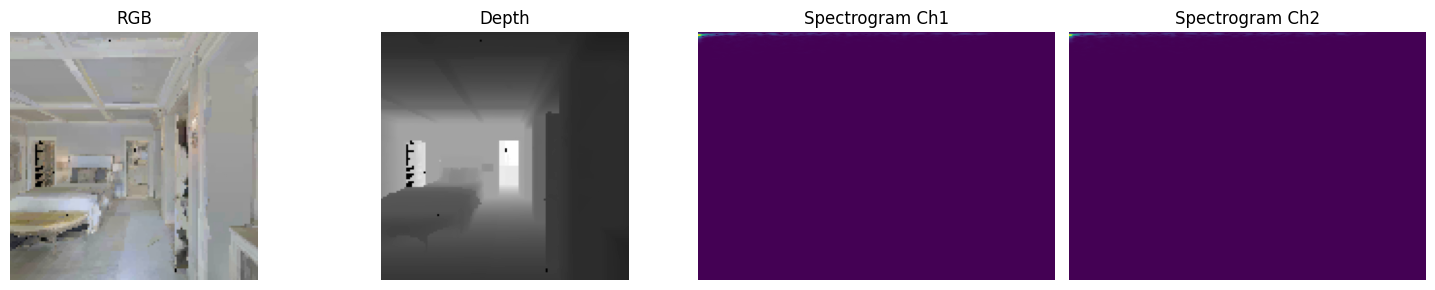

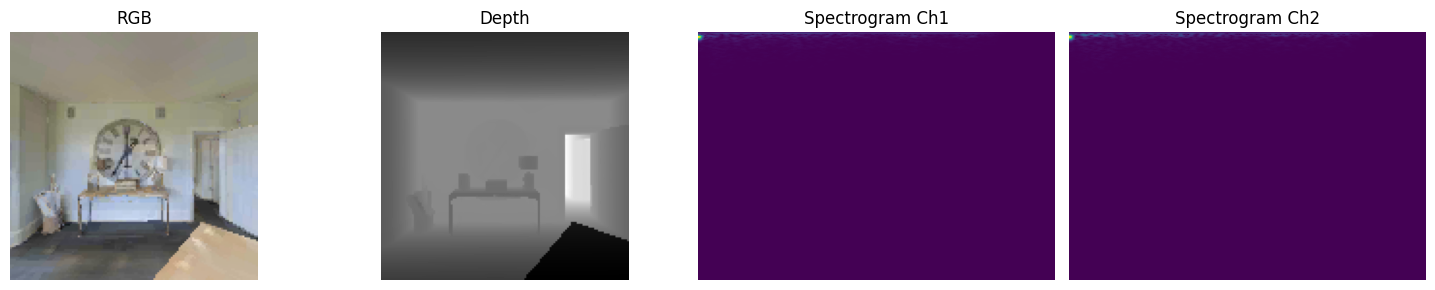

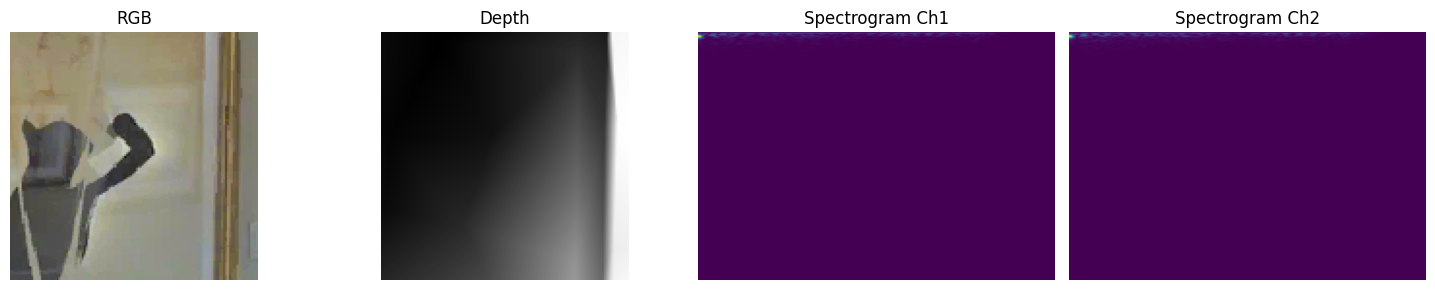

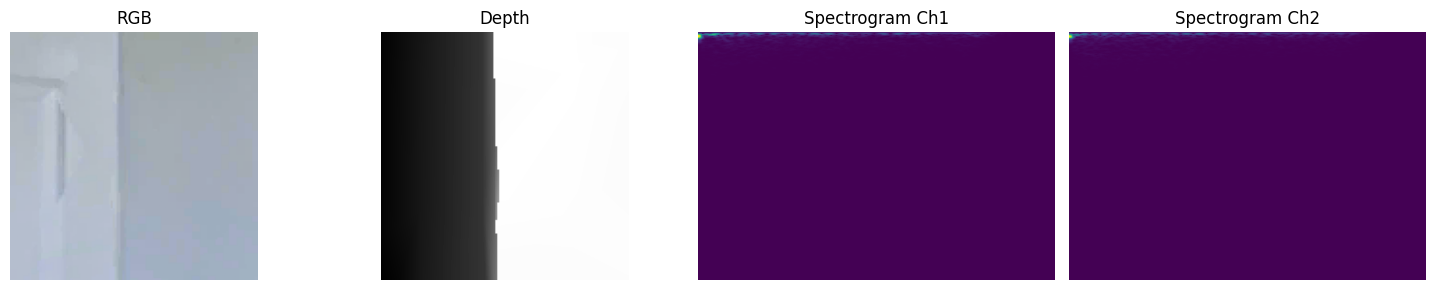

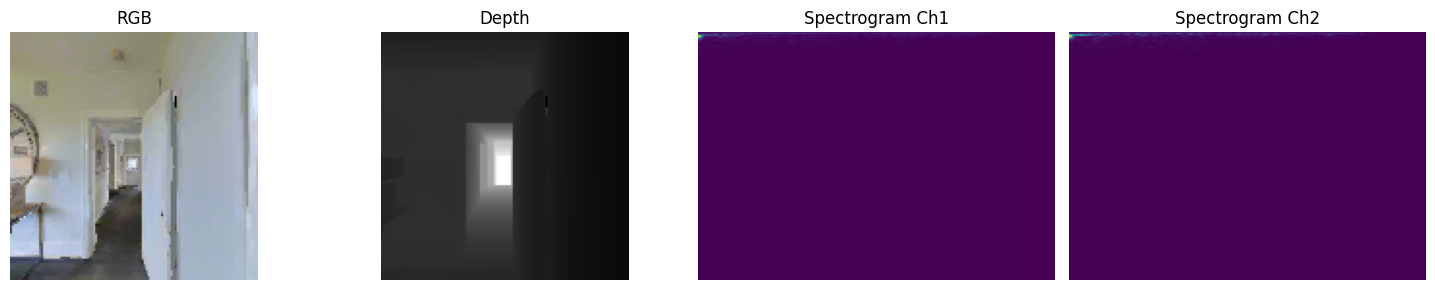

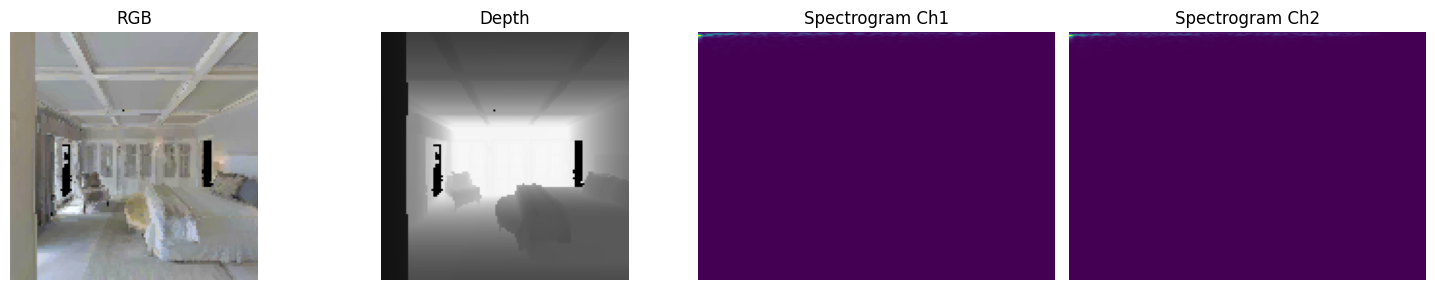

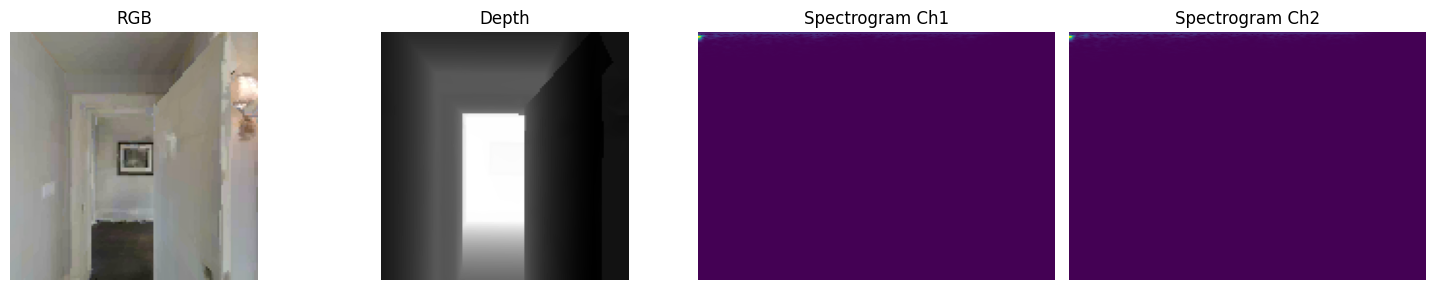

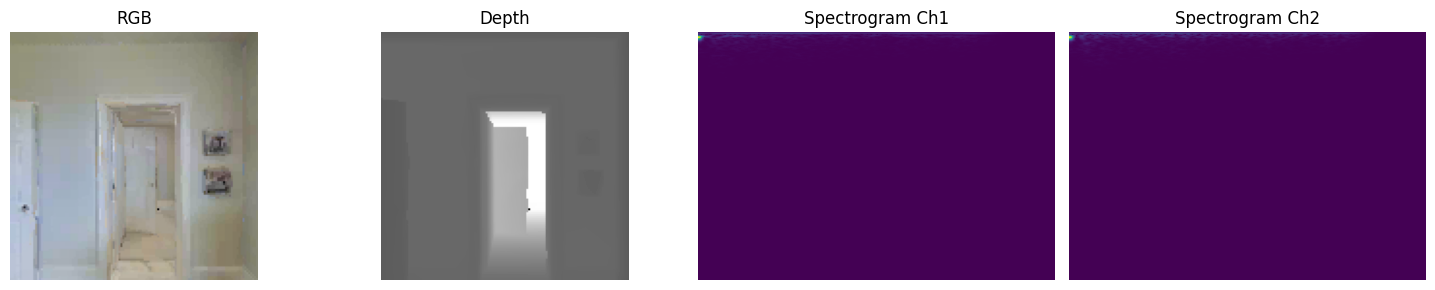

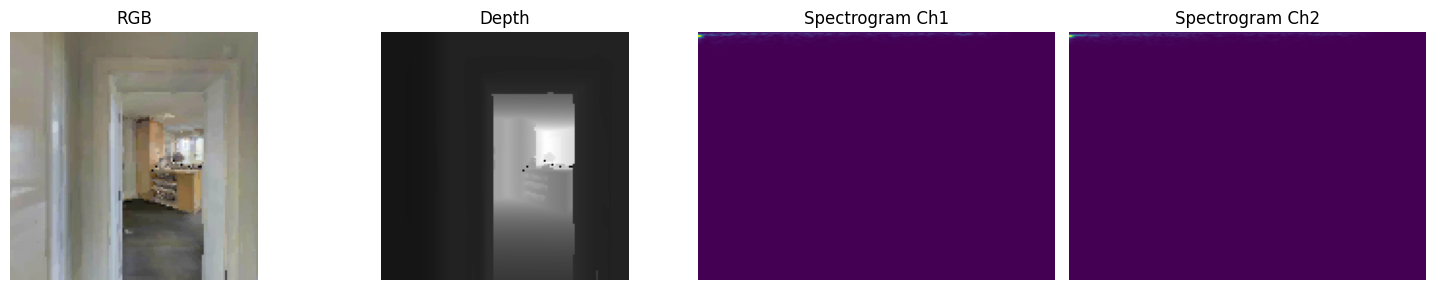

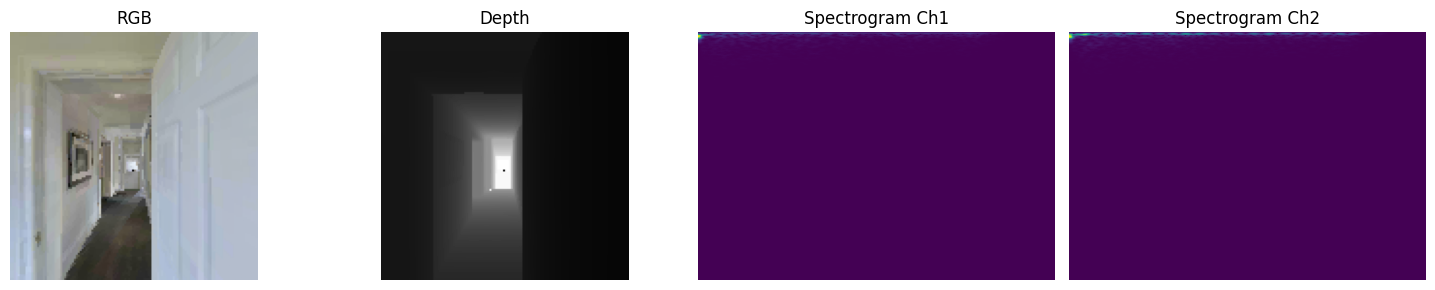

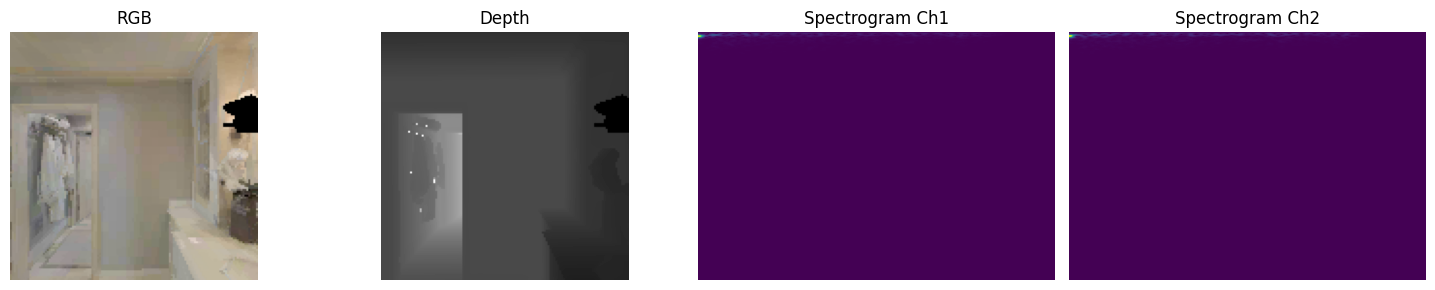

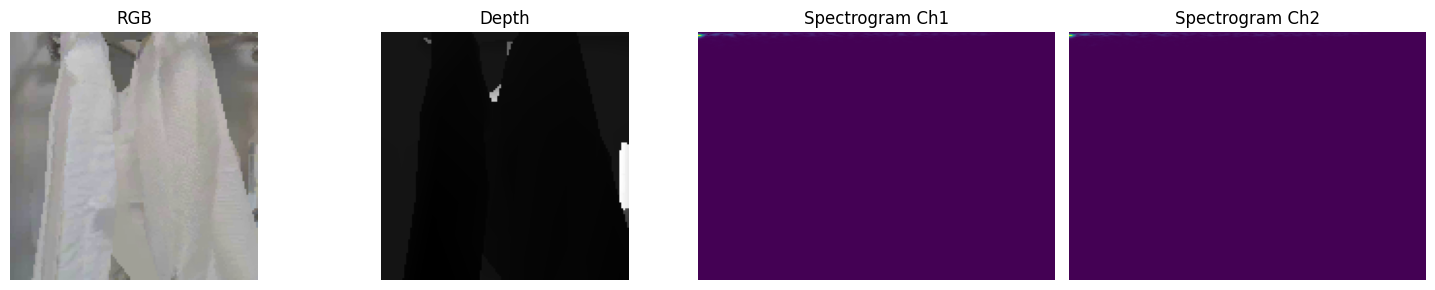

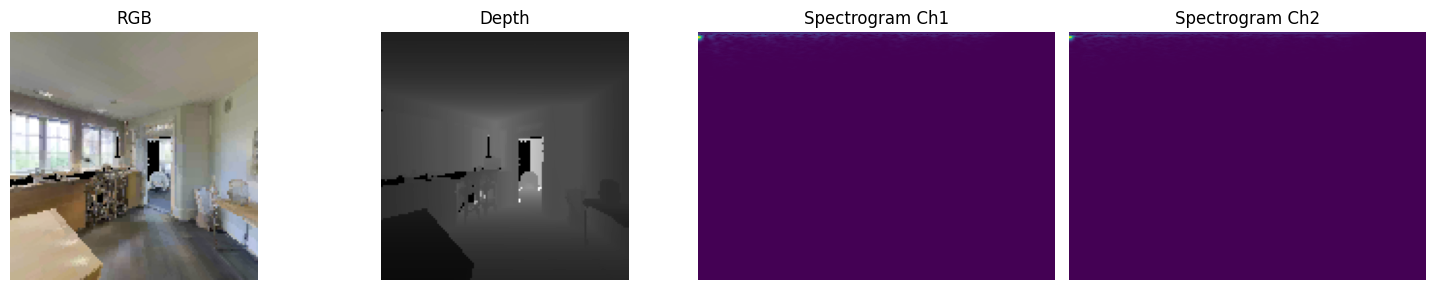

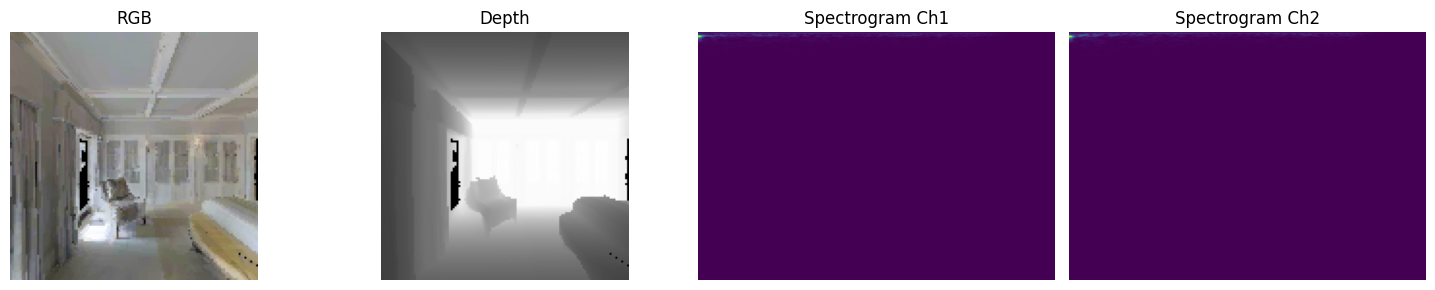

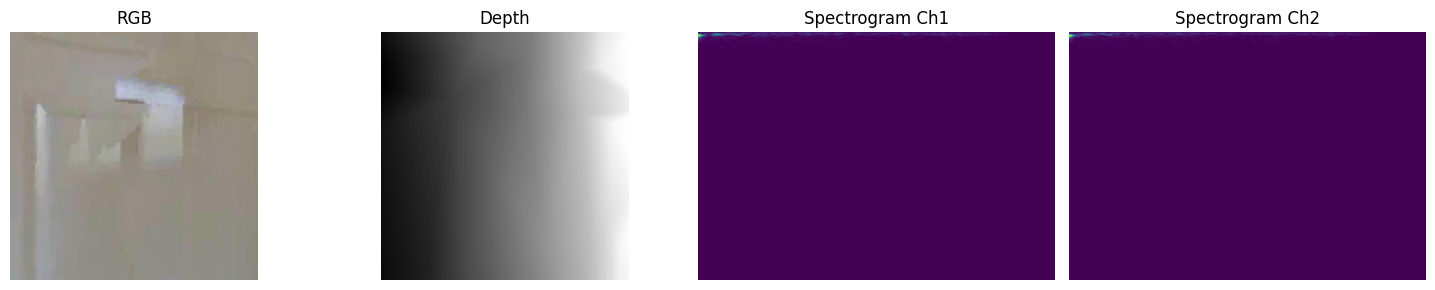

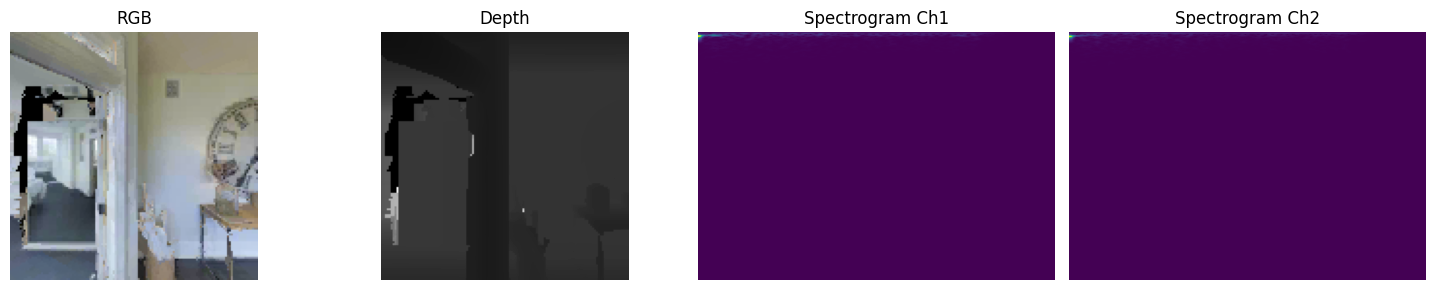

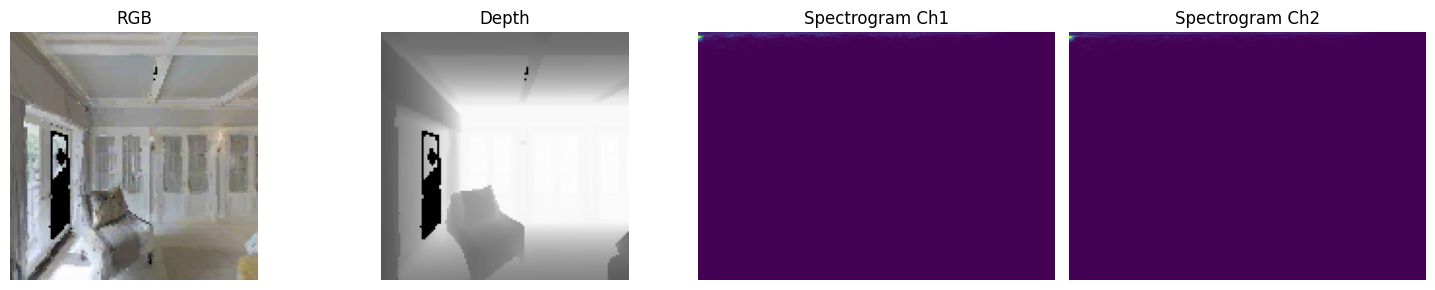

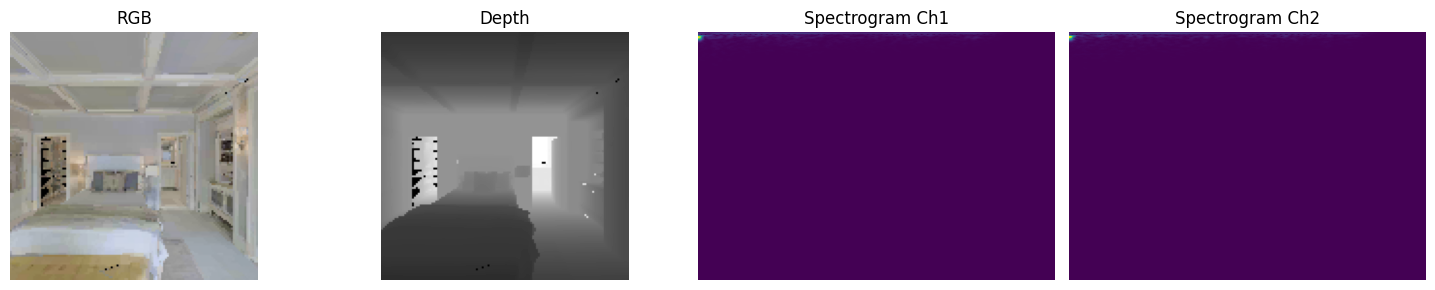

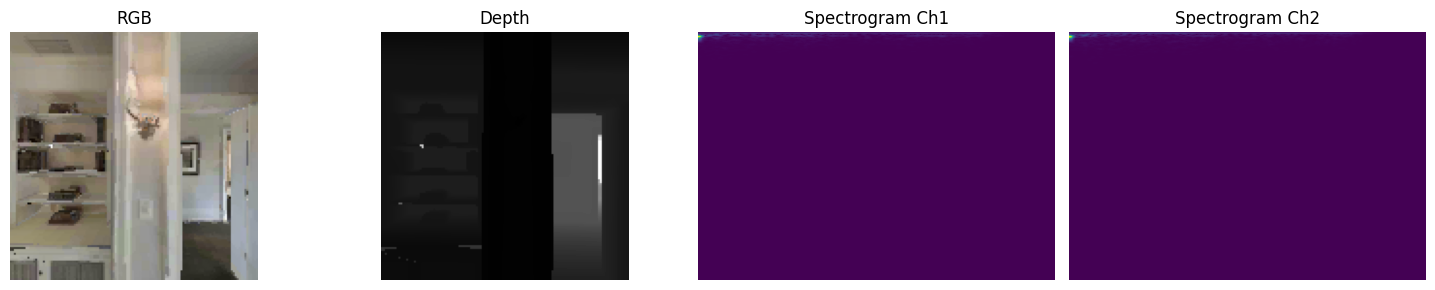

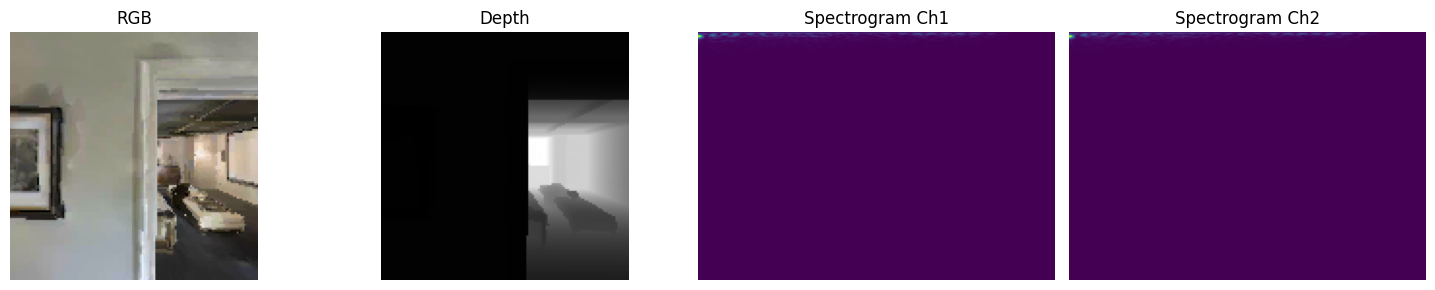

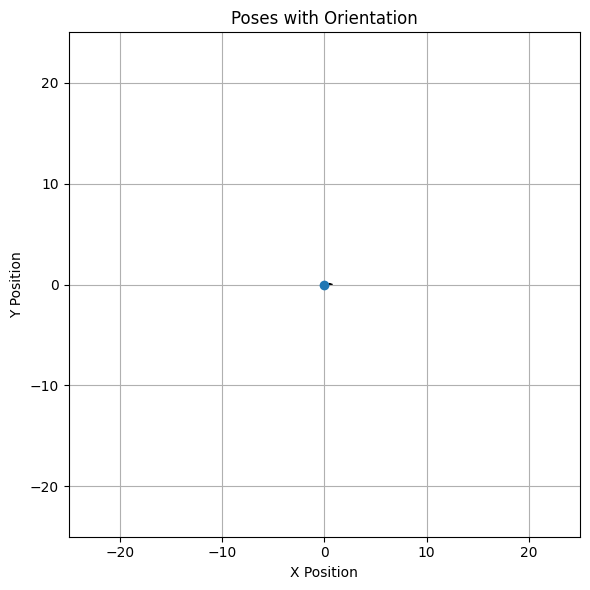

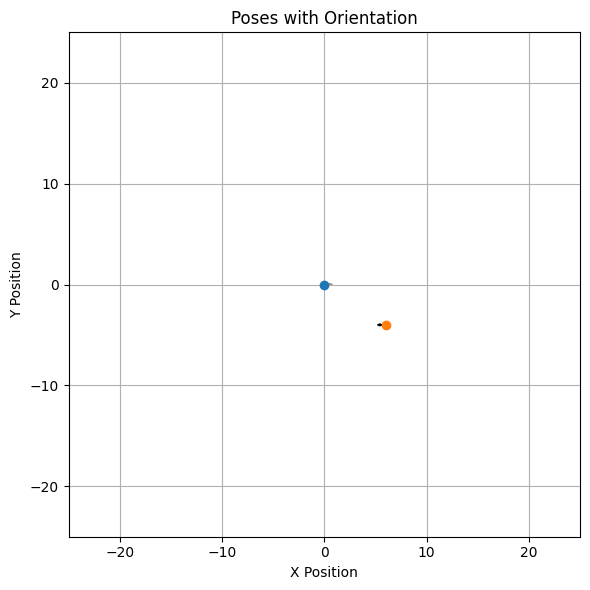

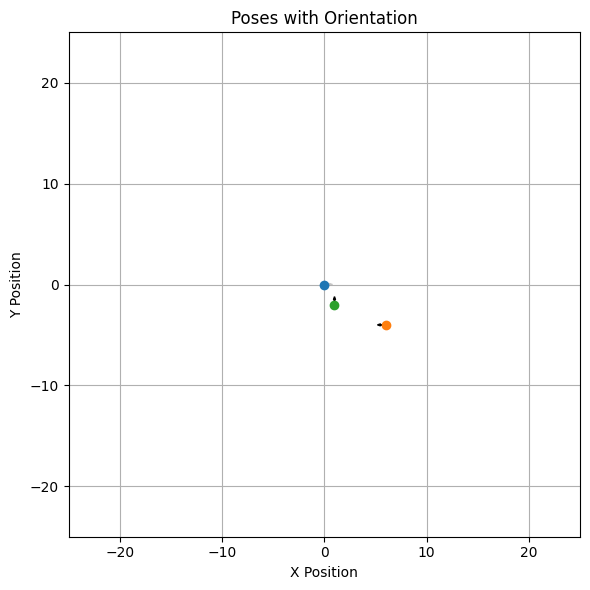

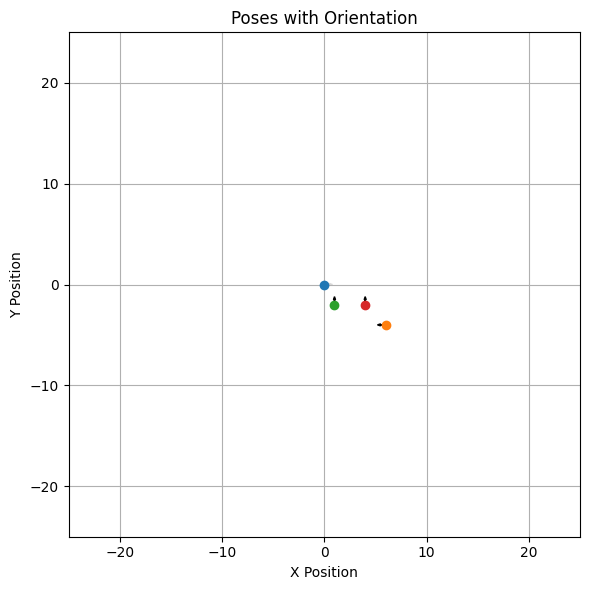

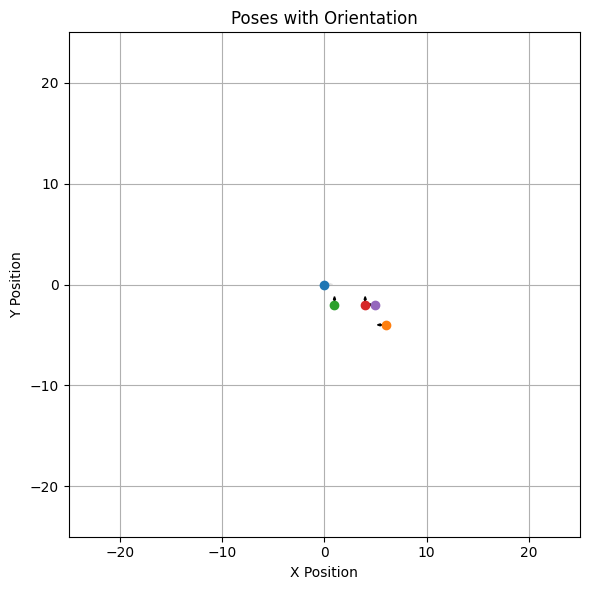

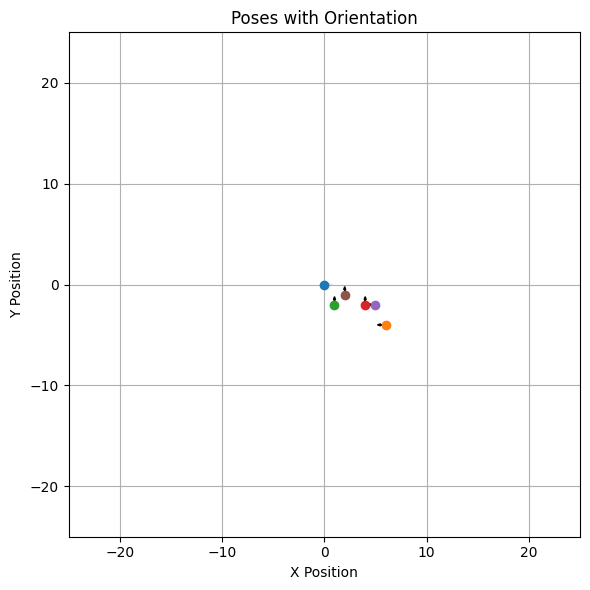

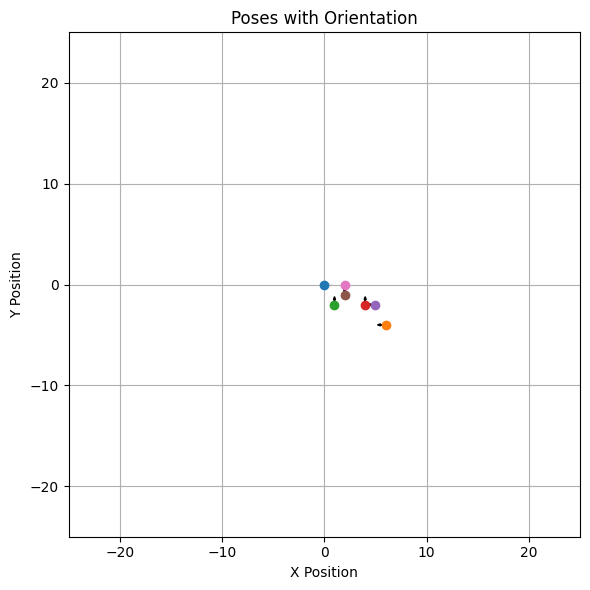

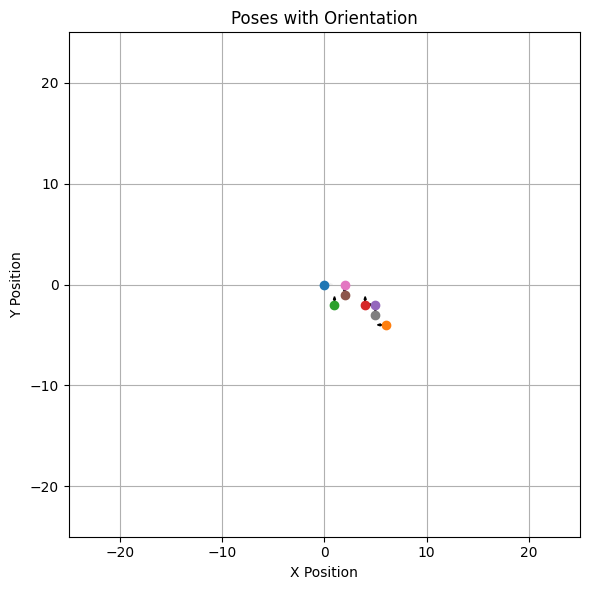

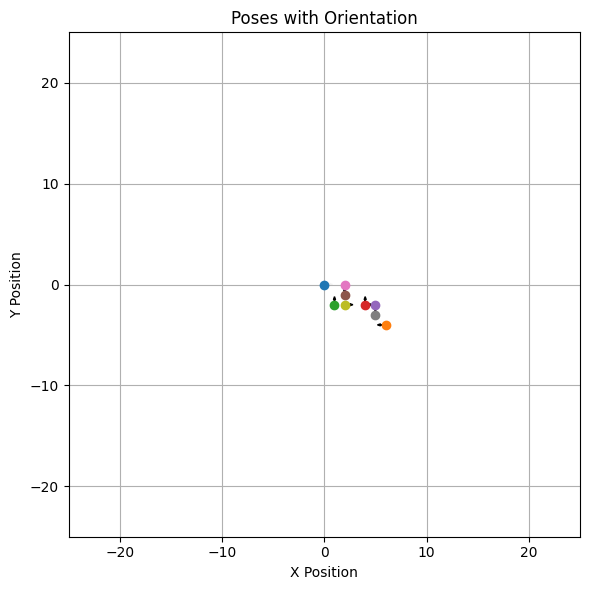

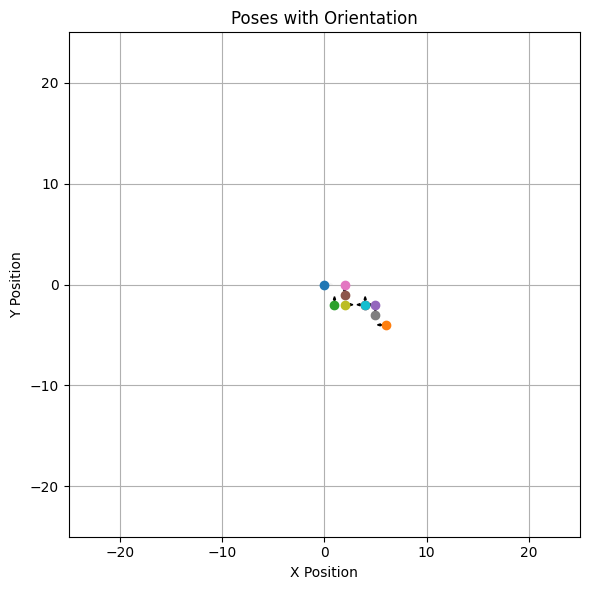

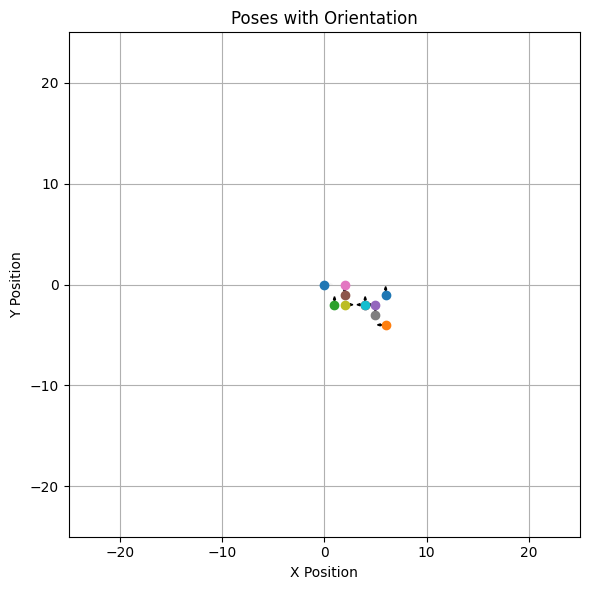

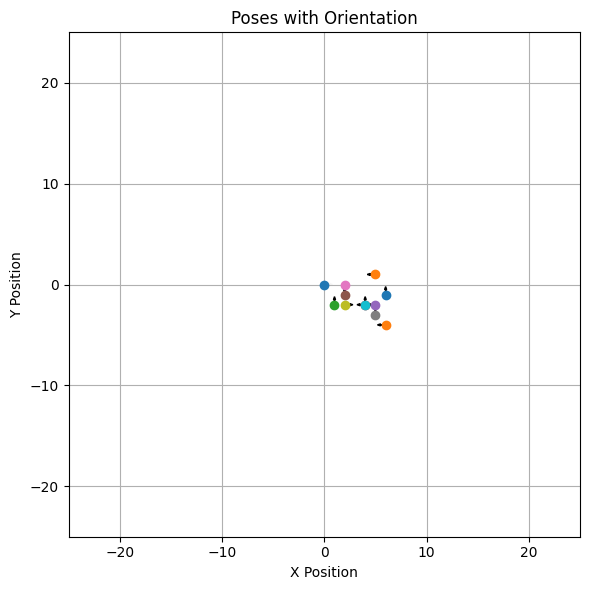

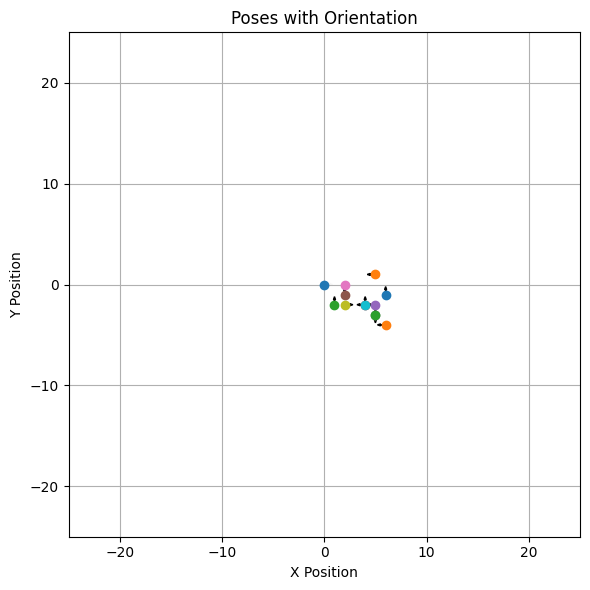

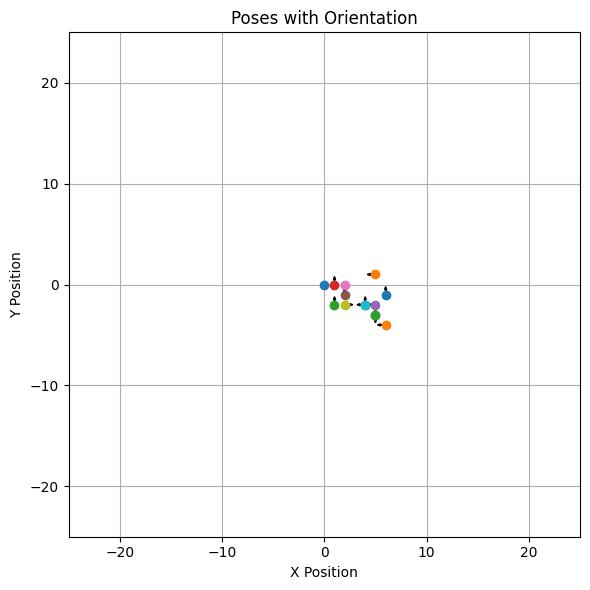

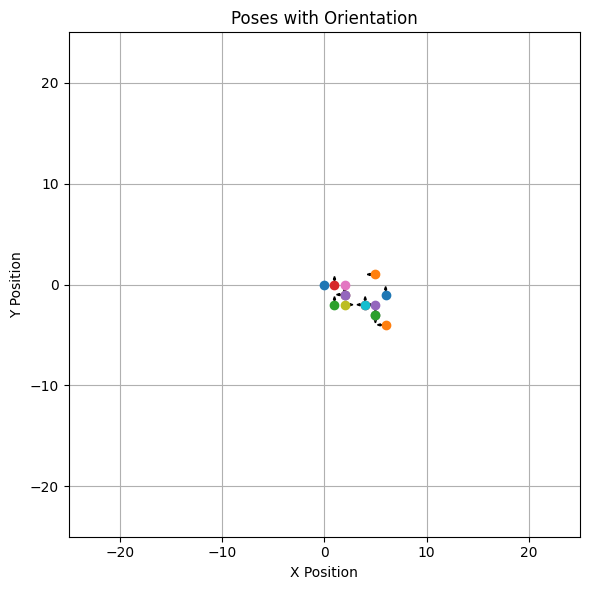

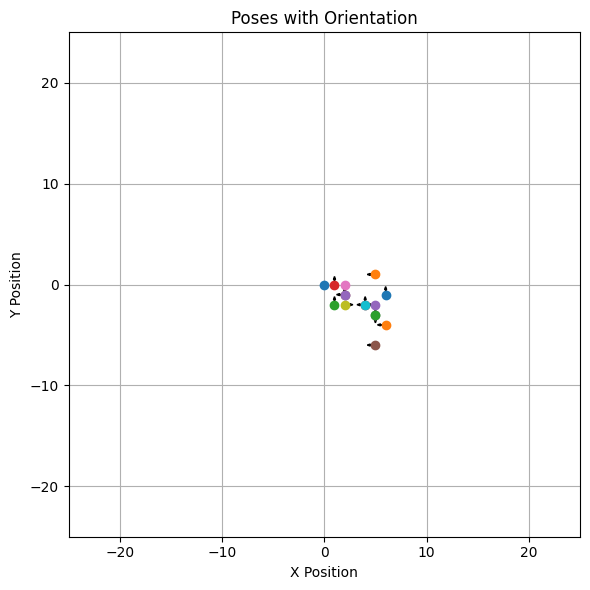

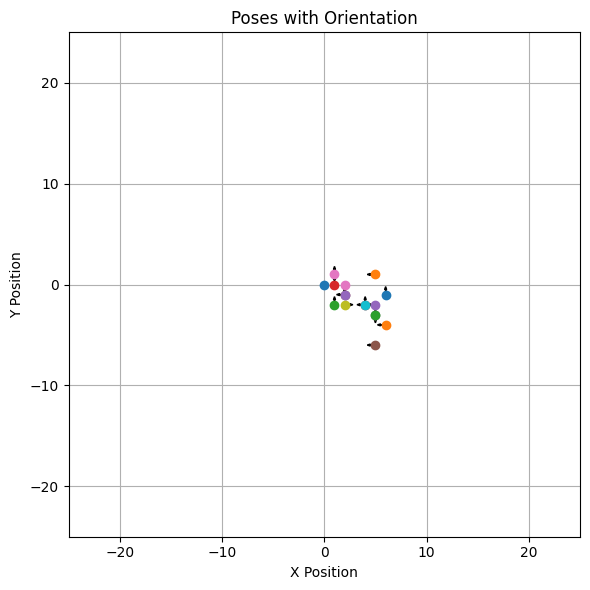

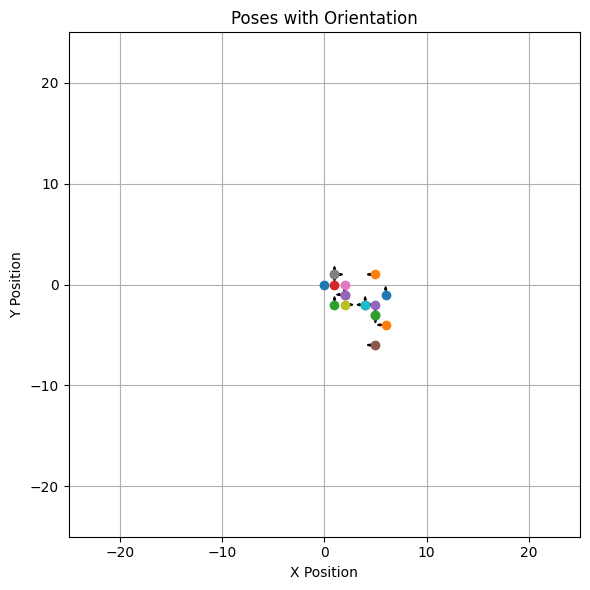

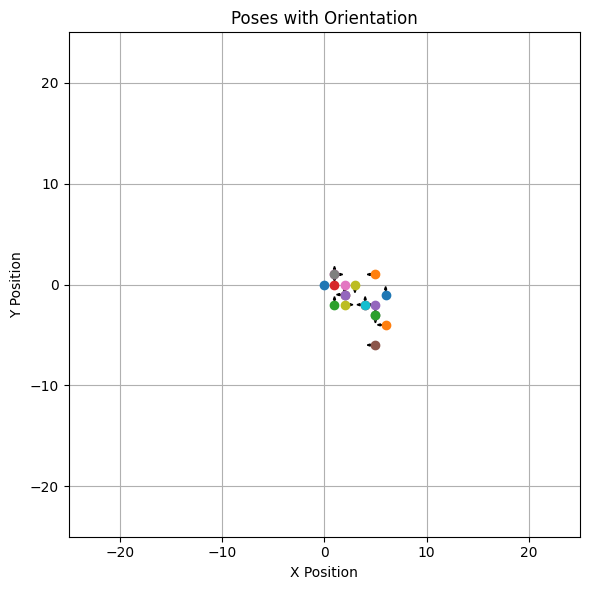

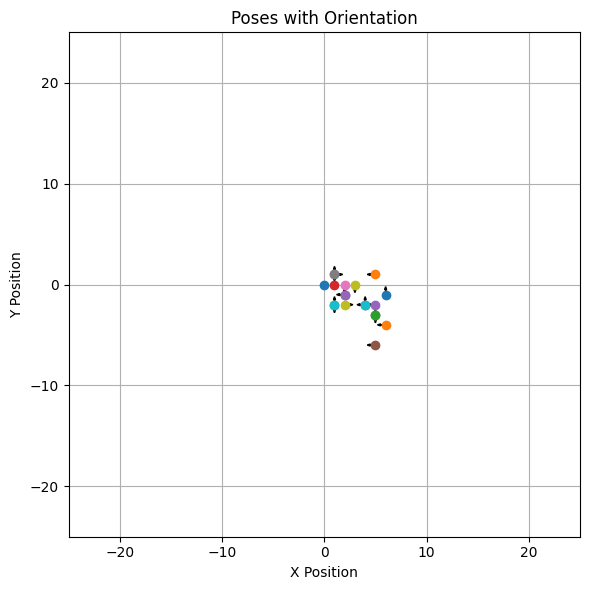

In [11]:
# Extract the relevant data
views = fs_rir_context_obs['context']['views']
echoes_mag = fs_rir_context_obs['context']['echoes_mag']
poses = fs_rir_context_obs['context']['poses']
query_poses = fs_rir_context_obs['query']['poses']

# Plot and save the visualizations
visualization_files = []
for i in range(views.shape[0]): #views.shape[0]
    rgb = views[i, :, :, :3]  # First three channels for RGB
    depth = views[i, :, :, 3]  # Fourth channel for Depth
    echoes = echoes_mag[i]

    plot_rgb_depth_spect(rgb, torch.tensor(depth), echoes)

pose_data = [pose for pose in poses]
for i in range(len(pose_data)):
    plot_poses_with_orientation(pose_data[:i+1], plot_line=False, pad=30)
plt.show()

/tmp/ipykernel_1060763/3895025047.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Greys')


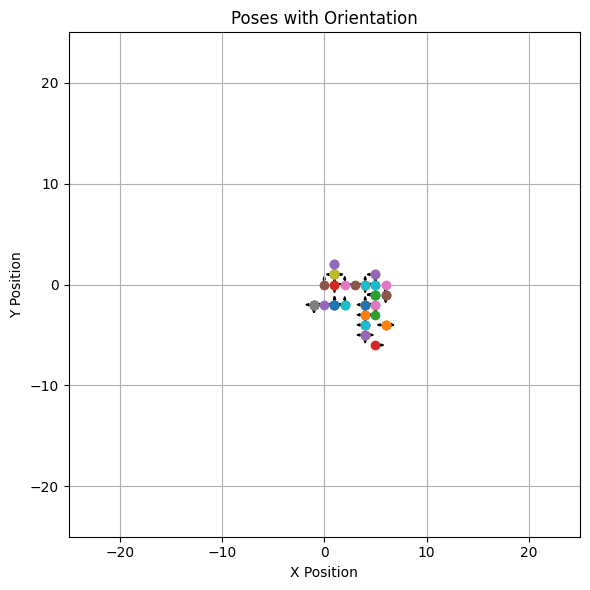

In [12]:
plot_poses_with_orientation(query_poses, plot_line=False)
plt.show()

In [13]:
query_poses

array([[ 1.       ,  2.       , -5.       , -3.       ,  0.       ],
       [ 1.       , -1.       , -6.       , -2.       , -1.5707964],
       [ 2.       ,  2.       , -4.       , -4.       ,  1.5707964],
       [-1.       ,  2.       ,  0.       , -2.       , -3.1415927],
       [ 0.       ,  2.       , -1.       ,  2.       ,  0.       ],
       [ 5.       ,  2.       , -1.       , -2.       , -1.5707964],
       [ 5.       , -1.       , -4.       , -3.       , -1.5707964],
       [ 4.       ,  3.       , -6.       ,  0.       , -3.1415927],
       [ 1.       ,  0.       , -3.       ,  0.       ,  0.       ],
       [ 2.       ,  2.       , -4.       , -4.       , -3.1415927],
       [ 1.       , -2.       , -5.       , -6.       , -1.5707964],
       [ 4.       ,  3.       , -5.       , -2.       ,  1.5707964],
       [ 1.       , -1.       , -6.       , -2.       ,  0.       ],
       [ 6.       ,  4.       , -6.       , -5.       ,  0.       ],
       [ 1.       , -2.       , -4

In [14]:
fs_rir_preds_obs = fs_rir_preds_obs.cpu().squeeze()

/tmp/ipykernel_1060763/743158727.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


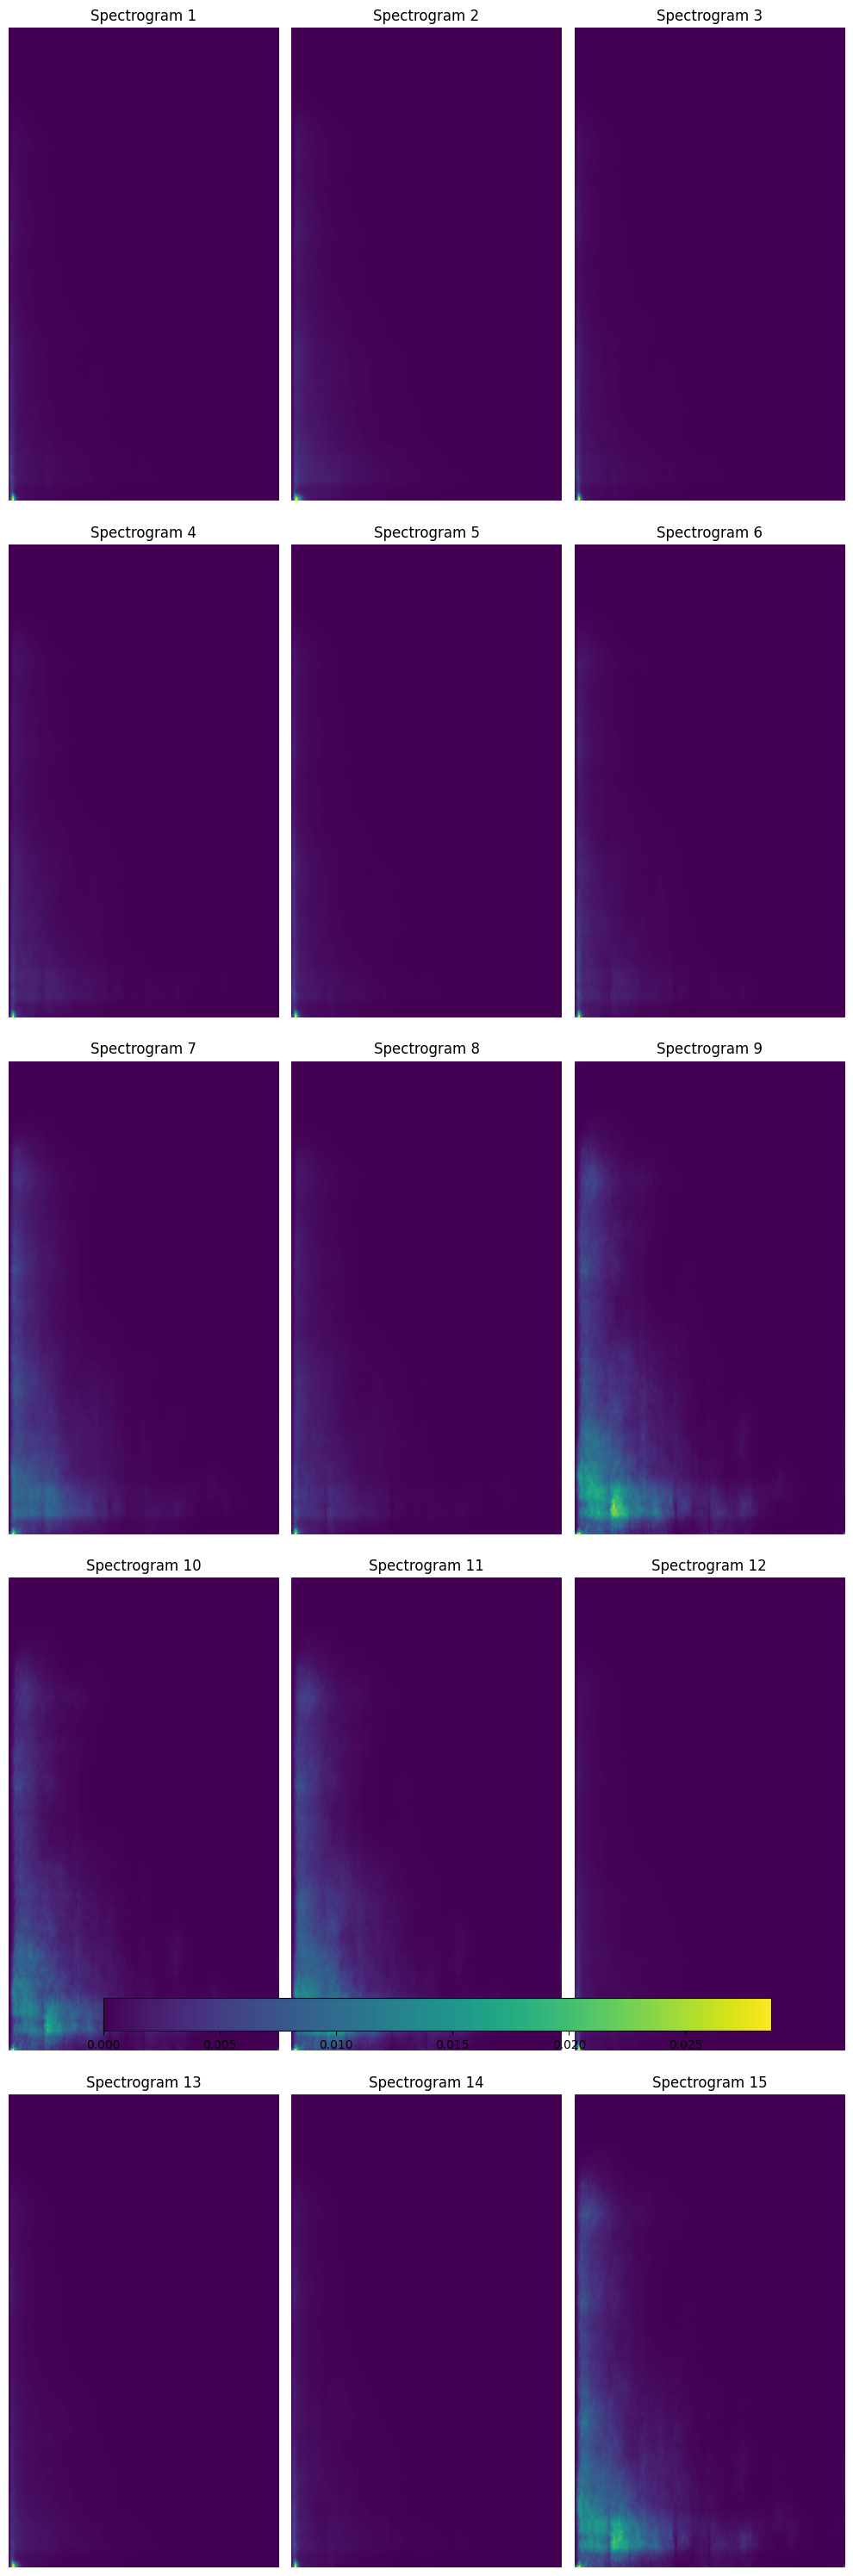

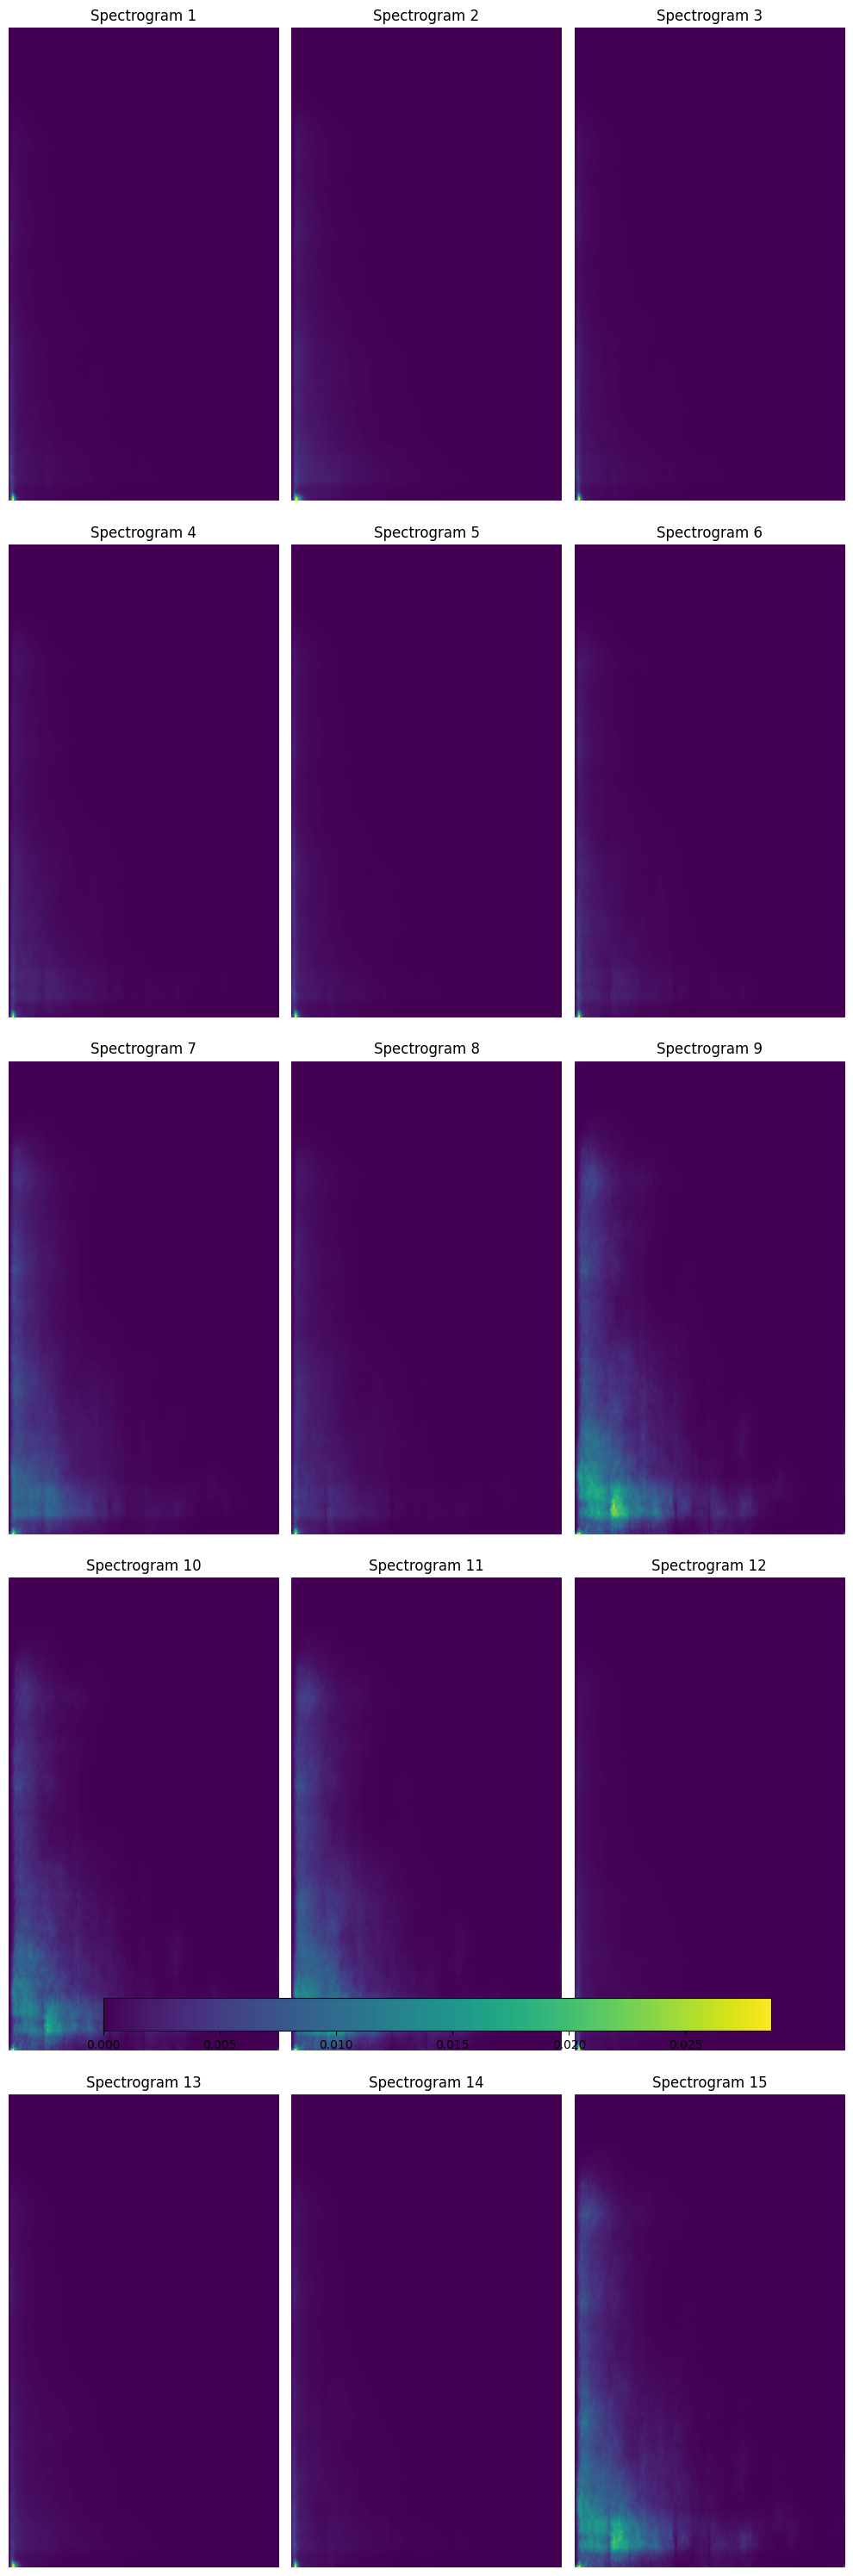

In [15]:
plot_log_spectrograms_grid(pred_rirs)

/tmp/ipykernel_1060763/743158727.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


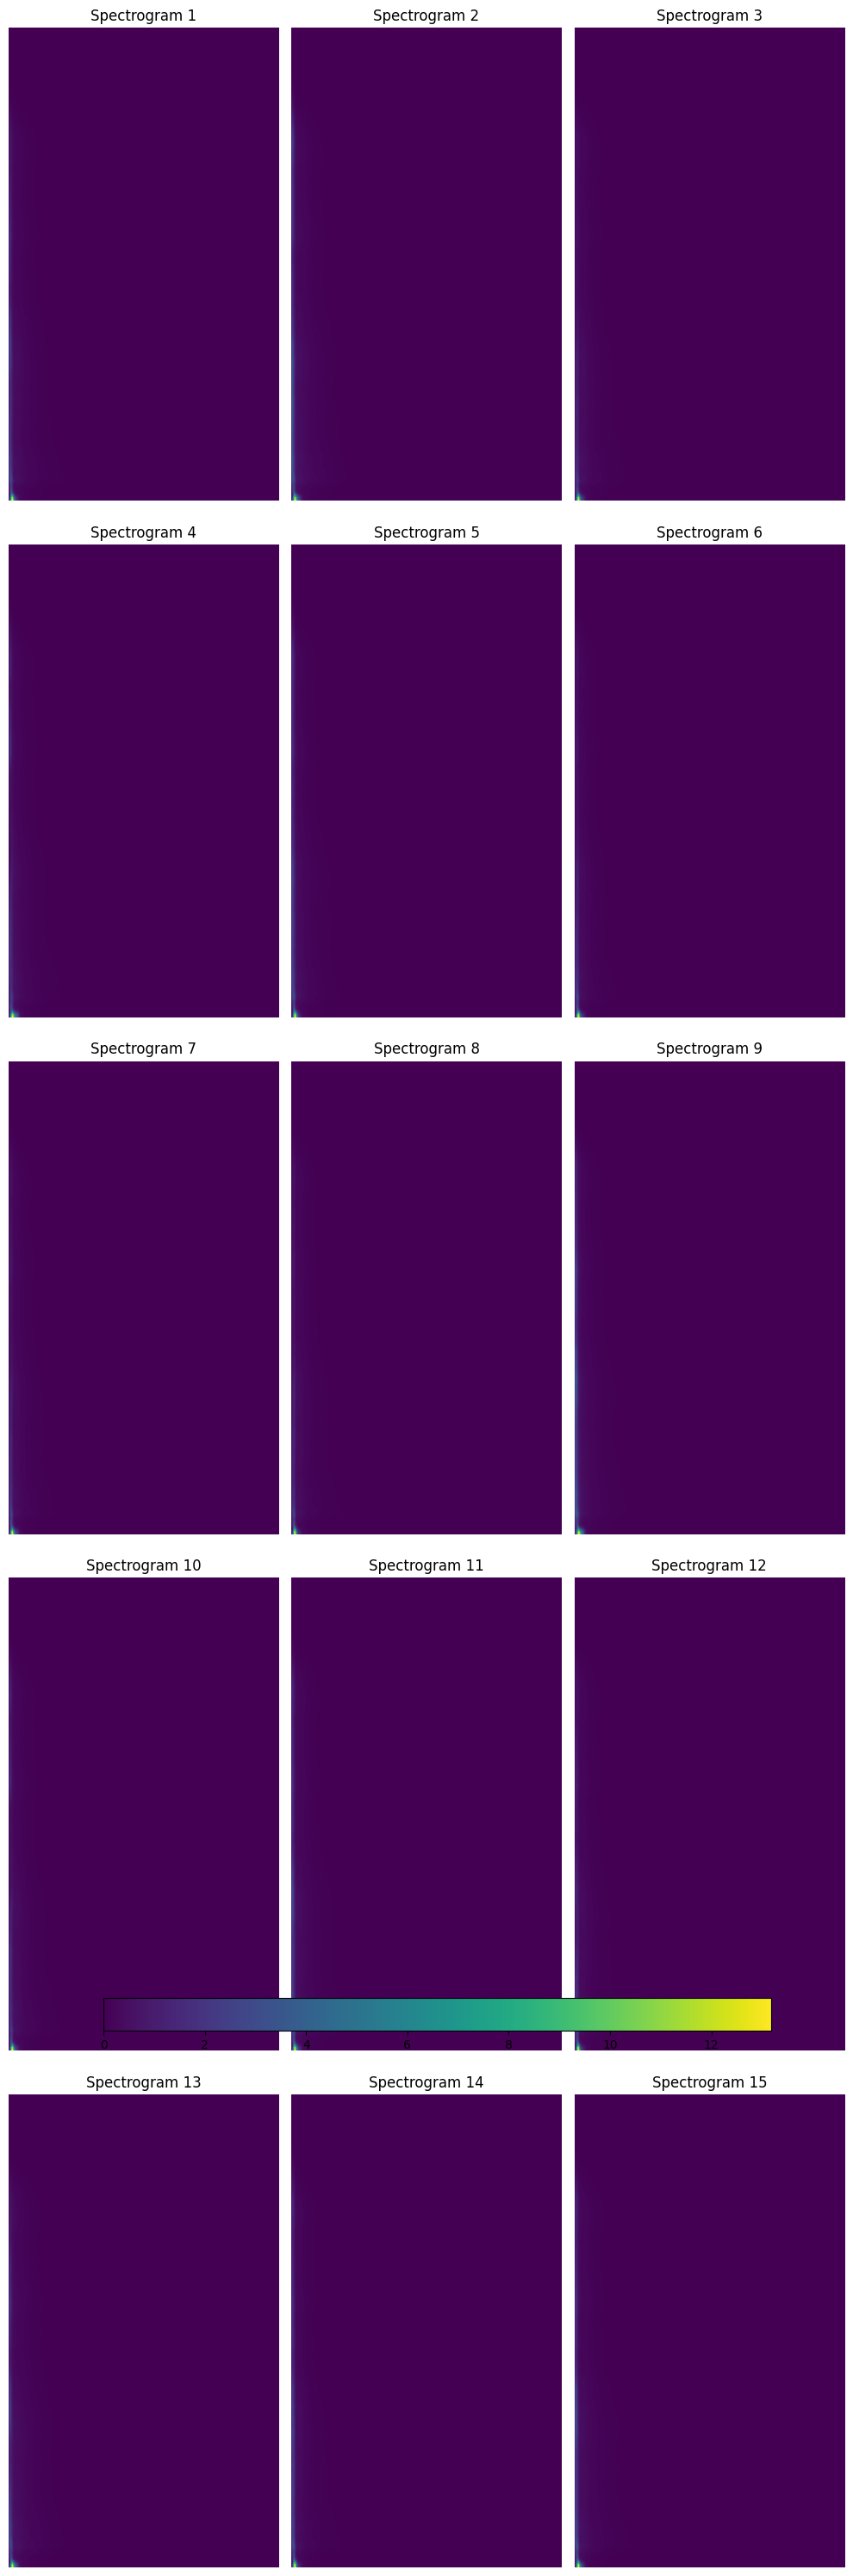

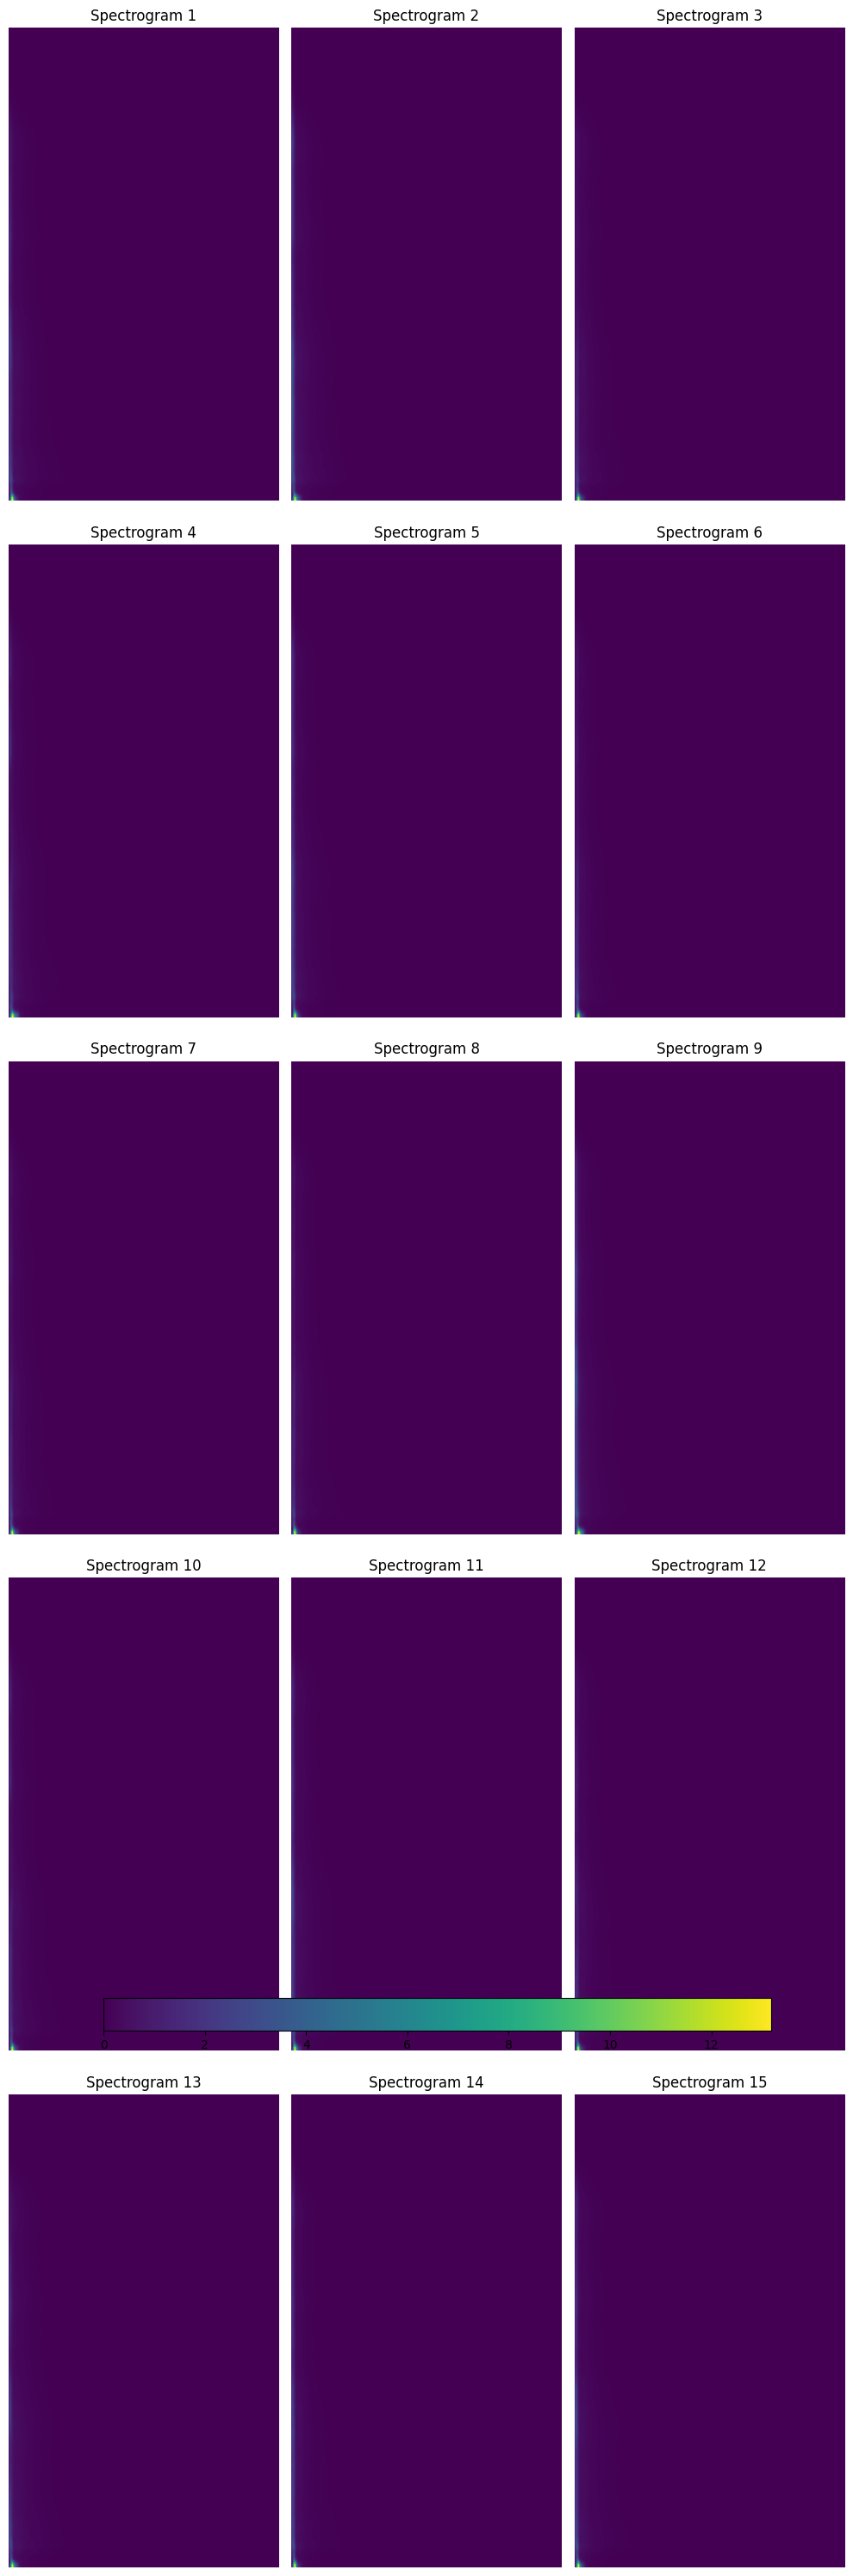

In [16]:
plot_log_spectrograms_grid(fs_rir_preds_obs)